In [1]:
import torch
import torch.nn as nn
import pandas as pd
from transformers import AutoTokenizer, AutoModel
from rouge_score import rouge_scorer
from bert_score import score as bert_score
import numpy as np
import os

try:
    from py_vncorenlp import VnCoreNLP
    rdrsegmenter = VnCoreNLP("https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/VnCoreNLP-1.2.jar", annotators="wseg,pos,ner,parse", max_heap_size='-Xmx2g')
    USE_VNCORENLP = True
except:
    USE_VNCORENLP = False
    import re

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")
phobert = AutoModel.from_pretrained("vinai/phobert-base").to(DEVICE)
class PhoBERTSUM(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Linear(
            encoder.config.hidden_size, 1
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        cls_embeddings = outputs.last_hidden_state[:, 0, :]
        scores = self.classifier(cls_embeddings)
        return scores
model = PhoBERTSUM(phobert).to(DEVICE)
model.eval()   # inference mode
def sent_tokenize(text):
    if not isinstance(text, str):
        return []
    text = text.strip()
    if not text:
        return []
    
    if USE_VNCORENLP:
        try:
            sentences = rdrsegmenter.sent_tokenize(text)
            sentences = [s.strip() for s in sentences if len(s.strip()) > 10]
            return sentences
        except:
            pass
    
    sentences = re.split(r'[.!?]+\s+', text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 10]
    return sentences

def split_sentences(text):
    if not isinstance(text, str):
        return []
    sentences = sent_tokenize(text)
    return [s.strip() for s in sentences if len(s.strip()) > 10]
def get_top_k_by_ratio(num_sentences, ratio=0.6):
    return max(1, int(num_sentences * ratio))
def encode_sentences(sentences, max_len=256):
    encoded = tokenizer(
        sentences,
        padding=True,
        truncation=True,
        max_length=max_len,
        return_tensors="pt"
    )
    return encoded["input_ids"].to(DEVICE), encoded["attention_mask"].to(DEVICE)
@torch.no_grad()
def extractive_summary(text, ratio=0.6):
    sentences = split_sentences(text)
    n = len(sentences)

    if n == 0:
        return ""

    # Nếu chỉ có 1 câu → lấy luôn
    if n == 1:
        return sentences[0]

    top_k = get_top_k_by_ratio(n, ratio)

    input_ids, attention_mask = encode_sentences(sentences)
    scores = model(input_ids, attention_mask)

    scores = scores.squeeze().cpu()

    # ĐẢM BẢO top_idx LUÔN là list
    top_idx = torch.topk(
        scores, min(top_k, n)
    ).indices.tolist()

    if not isinstance(top_idx, list):
        top_idx = [top_idx]

    top_idx.sort()

    summary = " ".join(sentences[i] for i in top_idx)
    return summary

rouge_scorer_obj = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)

def evaluate_summary(candidate, reference):
    if not candidate or not reference:
        return {
            'f1': 0.0,
            'rouge1': 0.0,
            'rougel': 0.0,
            'bertscore': 0.0
        }
    
    rouge_scores = rouge_scorer_obj.score(reference, candidate)
    rouge1 = rouge_scores['rouge1'].fmeasure
    rougel = rouge_scores['rougeL'].fmeasure
    
    try:
        P, R, F1_bert = bert_score([candidate], [reference], lang='vi', verbose=False)
        bertscore = F1_bert.item()
    except:
        bertscore = 0.0
    
    candidate_tokens = set(candidate.lower().split())
    reference_tokens = set(reference.lower().split())
    if len(reference_tokens) == 0:
        f1 = 0.0
    else:
        intersection = candidate_tokens & reference_tokens
        precision = len(intersection) / len(candidate_tokens) if len(candidate_tokens) > 0 else 0
        recall = len(intersection) / len(reference_tokens) if len(reference_tokens) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    
    return {
        'f1': f1,
        'rouge1': rouge1,
        'rougel': rougel,
        'bertscore': bertscore
    }

def select_best_summary(summaries_dict):
    if not summaries_dict:
        return None, {}
    
    best_key = None
    best_scores = None
    
    for key, scores in summaries_dict.items():
        if best_key is None:
            best_key = key
            best_scores = scores
            continue
        
        if scores['f1'] > best_scores['f1']:
            best_key = key
            best_scores = scores
        elif scores['f1'] == best_scores['f1']:
            if scores['rougel'] > best_scores['rougel']:
                best_key = key
                best_scores = scores
            elif scores['rougel'] == best_scores['rougel']:
                if scores['rouge1'] > best_scores['rouge1']:
                    best_key = key
                    best_scores = scores
                elif scores['rouge1'] == best_scores['rouge1']:
                    if scores['bertscore'] > best_scores['bertscore']:
                        best_key = key
                        best_scores = scores
    
    return best_key, best_scores




c:\Users\minhv\anaconda3\envs\pytorch-env\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [ ]:
INPUT_XLSX = r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset extractive\DATA_TX.xlsx"
OUTPUT_XLSX = r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset extractive\DATA_TX_summary.xlsx"

df = pd.read_excel(INPUT_XLSX)

if 'f1' not in df.columns:
    df['f1'] = np.nan
if 'rougel' not in df.columns:
    df['rougel'] = np.nan
if 'rouge1' not in df.columns:
    df['rouge1'] = np.nan
if 'bertscore' not in df.columns:
    df['bertscore'] = np.nan

reference_col = None
for col in ['reference_summary', 'gold_summary', 'reference', 'gold']:
    if col in df.columns:
        reference_col = col
        break

for idx, row in df.iterrows():
    content = row["content"]
    if pd.isna(content) or content == "":
        continue
    
    reference = ""
    if reference_col and reference_col in row:
        ref_val = row[reference_col]
        if not pd.isna(ref_val) and ref_val != "":
            reference = str(ref_val)
    elif not pd.isna(row.get("summary", "")) and row.get("summary", "") != "":
        reference = str(row["summary"])
    
    best_summary = None
    best_scores = None
    
    for retry in range(5):
        summary = extractive_summary(content, ratio=0.6)
        
        if reference and reference.strip():
            scores = evaluate_summary(summary, reference)
        else:
            scores = {'f1': 0.0, 'rouge1': 0.0, 'rougel': 0.0, 'bertscore': 0.0}
        
        if (scores['f1'] >= 0.5 and 
            scores['rouge1'] >= 0.45 and 
            scores['rougel'] >= 0.4 and 
            scores['bertscore'] >= 0.8):
            best_summary = summary
            best_scores = scores
            break
    
    if best_summary is not None:
        df.at[idx, "summary"] = best_summary
        df.at[idx, "f1"] = best_scores['f1']
        df.at[idx, "rougel"] = best_scores['rougel']
        df.at[idx, "rouge1"] = best_scores['rouge1']
        df.at[idx, "bertscore"] = best_scores['bertscore']

df.to_excel(OUTPUT_XLSX, index=False)

print("✅ Đã tạo xong bản tóm tắt trích xuất")


c:\Users\minhv\anaconda3\envs\pytorch-env\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
c:\Users\minhv\anaconda3\envs\pytorch-env\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


✅ Đã tạo xong bản tóm tắt trích xuất


In [1]:
import pandas as pd

df = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset extractive\Data_TX_summary.xlsx")
data = df[:8459]
data[["f1", "rouge1", "rougel", "bertscore"]].mean()

f1           0.449950
rouge1       0.511442
rougel       0.431277
bertscore    0.766737
dtype: float64

In [ ]:
# Cell setup cho Kaggle - Cài đặt vncorenlp
# Chạy cell này trước khi chạy các cell khác trên Kaggle

!pip install py_vncorenlp

import os
os.environ['JAVA_HOME'] = '/usr/lib/jvm/java-8-openjdk-amd64'

from py_vncorenlp import VnCoreNLP

rdrsegmenter = VnCoreNLP(
    "https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/VnCoreNLP-1.2.jar",
    annotators="wseg,pos,ner,parse",
    max_heap_size='-Xmx2g'
)

print("✅ VnCoreNLP đã được khởi tạo")

In [2]:
import pandas as pd
from difflib import SequenceMatcher
import numpy as np
import re

try:
    from py_vncorenlp import VnCoreNLP
    rdrsegmenter = VnCoreNLP("https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/VnCoreNLP-1.2.jar", annotators="wseg,pos,ner,parse", max_heap_size='-Xmx2g')
    USE_VNCORENLP = True
except:
    USE_VNCORENLP = False

def sent_tokenize(text):
    if not isinstance(text, str):
        return []
    text = text.strip()
    if not text:
        return []
    
    if USE_VNCORENLP:
        try:
            sentences = rdrsegmenter.sent_tokenize(text)
            sentences = [s.strip() for s in sentences if len(s.strip()) > 10]
            return sentences
        except:
            pass
    
    sentences = re.split(r'[.!?]+\s+', text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 10]
    return sentences

def similarity(a, b):
    return SequenceMatcher(None, a.lower(), b.lower()).ratio()

def label_sentences(content, summary, threshold=0.7):
    if pd.isna(content) or content == "":
        return [], []
    
    if pd.isna(summary) or summary == "":
        content_sentences = sent_tokenize(str(content))
        return content_sentences, [0] * len(content_sentences)
    
    content_sentences = sent_tokenize(str(content))
    summary_sentences = sent_tokenize(str(summary))
    
    labels = []
    summary_set = [s.strip().lower() for s in summary_sentences if s.strip()]
    
    for sent in content_sentences:
        sent_clean = sent.strip()
        if len(sent_clean) < 10:
            labels.append(0)
            continue
        
        sent_lower = sent_clean.lower()
        is_in_summary = False
        
        for sum_sent in summary_set:
            sim = similarity(sent_lower, sum_sent)
            if sim >= threshold:
                is_in_summary = True
                break
        
        labels.append(1 if is_in_summary else 0)
    
    return content_sentences, labels

data = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset extractive\DATA_TX_work_sumnew.xlsx")
labeled_data = []

for idx, row in data.iterrows():
    content = row.get("content", "")
    summary = row.get("summary", "")
    
    sentences, labels = label_sentences(content, summary, threshold=0.7)
    
    for sent, label in zip(sentences, labels):
        labeled_data.append({
            'doc_id': idx,
            'sentence': sent,
            'label': label,
            'content': content,
            'summary': summary
        })

df_labeled = pd.DataFrame(labeled_data)

output_path = r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset extractive\Data_TX_final.xlsx"
df_labeled.to_excel(output_path, index=False)

print(f"✅ Đã gắn nhãn {len(df_labeled)} câu")
print(f"   - Số câu được chọn (label=1): {df_labeled['label'].sum()}")
print(f"   - Số câu không được chọn (label=0): {(df_labeled['label'] == 0).sum()}")
print(f"   - Tỷ lệ: {df_labeled['label'].mean():.2%}")

✅ Đã gắn nhãn 241930 câu
   - Số câu được chọn (label=1): 83225
   - Số câu không được chọn (label=0): 158705
   - Tỷ lệ: 34.40%


In [2]:
import pandas as pd
df = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset extractive\Data_TX_work_summary_labeled.xlsx")
df

,doc_id,sentence,label,content,summary
0,0,"Bé Lê ho, bà ạ",0,"Bé Lê ho, bà ạ.\nBà bế bé Lê.\nA, ba!\nBa bế c...","Ba bế cả Hà , cả bé Lê ."
1,0,Bà bế bé Lê,0,"Bé Lê ho, bà ạ.\nBà bế bé Lê.\nA, ba!\nBa bế c...","Ba bế cả Hà , cả bé Lê ."
2,0,"Ba bế cả Hà, cả bé Lê.",1,"Bé Lê ho, bà ạ.\nBà bế bé Lê.\nA, ba!\nBa bế c...","Ba bế cả Hà , cả bé Lê ."
3,1,"Bé Li bi bô:\nBi, Bi",0,"Bé Li bi bô:\nBi, Bi.\nBé ạ đi.\nBé ạ lia lịa,...",Bi dỗ bé .
4,1,"Bé ạ lia lịa, bé bị ho",0,"Bé Li bi bô:\nBi, Bi.\nBé ạ đi.\nBé ạ lia lịa,...",Bi dỗ bé .
...,...,...,...,...,...
241925,10124,"Vào năm 1786, Nguyễn Huệ còn dùng con đường nà...",0,Bà vợ này có tài thuần phục voi1. Đúng hay sai...,Một khía_cạnh khác của phong_trào Tây_Sơn có ý...
241926,10124,Một nhà nghiên cứu người Việt còn khẳng định l...,0,Bà vợ này có tài thuần phục voi1. Đúng hay sai...,Một khía_cạnh khác của phong_trào Tây_Sơn có ý...
241927,10124,Sự đồng hóa Tây Sơn với phía tây đã khiến các ...,0,Bà vợ này có tài thuần phục voi1. Đúng hay sai...,Một khía_cạnh khác của phong_trào Tây_Sơn có ý...
241928,10124,"Để kết luận, chúng ta có thể thấy qua chương n...",0,Bà vợ này có tài thuần phục voi1. Đúng hay sai...,Một khía_cạnh khác của phong_trào Tây_Sơn có ý...


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
import optuna
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from tqdm import tqdm
from torch.optim import AdamW

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained(
    "vinai/phobert-base",
    use_fast=False
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

class PhoBERTSUM(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Linear(encoder.config.hidden_size, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        sent_emb = outputs.last_hidden_state.mean(dim=1)
        return self.classifier(sent_emb)

class SentenceDataset(Dataset):
    def __init__(self, data, tokenizer, max_len=256):
        self.data = data.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        sentence = str(row['sentence'])
        label = float(row['label'])

        encoding = self.tokenizer(
            sentence,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(label, dtype=torch.float)
        }

def train_epoch(model, dataloader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    criterion = nn.BCEWithLogitsLoss()

    for batch in tqdm(dataloader, desc="Training"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs.squeeze(), labels)
        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

def validate(model, dataloader, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    criterion = nn.BCEWithLogitsLoss()

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs.squeeze(), labels)
            total_loss += loss.item()

            preds = (torch.sigmoid(outputs.squeeze()) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total if total > 0 else 0
    avg_loss = total_loss / len(dataloader)
    return avg_loss, accuracy

def objective(trial):
    data = pd.read_excel(r"/kaggle/working/dataset-tx/Data_TX_labeled.xlsx")

    train_data, val_data = train_test_split(data, test_size=0.2, random_state=42)

    learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 5e-4)
    batch_size = trial.suggest_categorical('batch_size', [8, 16, 32])
    max_len = trial.suggest_categorical('max_len', [128, 256])
    num_epochs = 5
    warmup_steps = trial.suggest_int('warmup_steps', 100, 800)

    # Define the tokenizer locally inside the function to avoid NameError
    tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    train_dataset = SentenceDataset(train_data, tokenizer, max_len=max_len)
    val_dataset = SentenceDataset(val_data, tokenizer, max_len=max_len)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    encoder = AutoModel.from_pretrained("vinai/phobert-base").to(DEVICE)
    model = PhoBERTSUM(encoder).to(DEVICE)

    optimizer = AdamW(model.parameters(), lr=learning_rate)
    total_steps = len(train_loader) * num_epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
    )

    best_val_loss = float('inf')
    patience = 2
    patience_counter = 0

    for epoch in range(num_epochs):
        train_loss = train_epoch(model, train_loader, optimizer, scheduler, DEVICE)
        val_loss, val_acc = validate(model, val_loader, DEVICE)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return best_val_loss

study = optuna.create_study(direction='minimize', pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=10, show_progress_bar=True)

print("Best parameters:")
print(study.best_params)
print(f"Best validation loss: {study.best_value:.4f}")

best_params = study.best_params

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
import pandas as pd
import os
from tqdm import tqdm
from torch.optim import AdamW

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained(
    "vinai/phobert-base",
    use_fast=False
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

class PhoBERTSUM(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Linear(encoder.config.hidden_size, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        sent_emb = outputs.last_hidden_state.mean(dim=1)
        return self.classifier(sent_emb)

class SentenceDataset(Dataset):
    def __init__(self, data, tokenizer, max_len=256):
        self.data = data.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        sentence = str(row['sentence'])
        label = float(row['label'])

        encoding = self.tokenizer(
            sentence,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(label, dtype=torch.float)
        }

def train_epoch(model, dataloader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    criterion = nn.BCEWithLogitsLoss()
    
    for batch in tqdm(dataloader, desc="Training"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs.squeeze(), labels)
        loss.backward()
        optimizer.step()
        scheduler.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)

def validate(model, dataloader, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    criterion = nn.BCEWithLogitsLoss()
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs.squeeze(), labels)
            total_loss += loss.item()
            
            preds = (torch.sigmoid(outputs.squeeze()) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    
    accuracy = correct / total if total > 0 else 0
    avg_loss = total_loss / len(dataloader)
    return avg_loss, accuracy

data = pd.read_excel(r"/kaggle/working/dataset-tx/Data_TX_labeled.xlsx")

train_data, val_data = train_test_split(data, test_size=0.2, random_state=42)
test_data, val_data = train_test_split(val_data, test_size=0.5, random_state=42)

best_params= {'learning_rate': 3.868107453864181e-05, 'batch_size': 32, 'max_len': 128, 'warmup_steps': 213}

learning_rate = best_params['learning_rate']
batch_size = best_params['batch_size']
max_len = best_params['max_len']
num_epochs = 10
warmup_steps = best_params['warmup_steps']

train_dataset = SentenceDataset(train_data, tokenizer, max_len=max_len)
val_dataset = SentenceDataset(val_data, tokenizer, max_len=max_len)
test_dataset = SentenceDataset(test_data, tokenizer, max_len=max_len)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

encoder = AutoModel.from_pretrained("vinai/phobert-base").to(DEVICE)
model = PhoBERTSUM(encoder).to(DEVICE)

optimizer = AdamW(model.parameters(), lr=learning_rate)
total_steps = len(train_loader) * num_epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

best_val_loss = float('inf')
best_model_state = None
patience = 3
patience_counter = 0

print(f"Training với tham số tối ưu:")
print(f"  Learning rate: {learning_rate}")
print(f"  Batch size: {batch_size}")
print(f"  Max length: {max_len}")
print(f"  Warmup steps: {warmup_steps}")
print(f"  Epochs: {num_epochs}")
print()

for epoch in range(num_epochs):
    print(f"Epoch {epoch + 1}/{num_epochs}")
    train_loss = train_epoch(model, train_loader, optimizer, scheduler, DEVICE)
    val_loss, val_acc = validate(model, val_loader, DEVICE)
    
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Loss: {val_loss:.4f}, Val Accuracy: {val_acc:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict().copy()
        patience_counter = 0
        print(f"  ✓ Model improved!")
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{patience})")
    
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch + 1}")
        break
    
    print()

if best_model_state:
    model.load_state_dict(best_model_state)

test_loss, test_acc = validate(model, test_loader, DEVICE)
print(f"\nFinal Test Results:")
print(f"  Test Loss: {test_loss:.4f}")
print(f"  Test Accuracy: {test_acc:.4f}")

model_save_path = r"/kaggle/working/phobert_summary_model.pth"
torch.save({
    'model_state_dict': model.state_dict(),
    'best_params': best_params,
    'test_loss': test_loss,
    'test_acc': test_acc
}, model_save_path)

print(f"\n✅ Model đã được lưu tại: {model_save_path}")

---

In [2]:
text = """Đạo Bàlamôn Theo nội dung tấm bia Võ Cạnh (thế kỷ thứ III) cho biết: Đạo Bàlamôn trở thành tôn giáo chính trong giai đoạn đầu của Vương quốc Lâm Ấp, Iihưng chỉ giứi vương tôn quý 
lộc mới có quyèn hành lễ và dự lễ. Buổi đầu, đạo Bàlamôn phát triển mạnh tại các tiểu vương phía Nam và từ thế kỷ thứ IV bắt đầu phát triển ra miền Bắc, dưới triều vua Bhadravarman 
I (Fan-houta hay Phạm Hồ Đạt), người sáng lập ra triều đại Gangaraja (sông Gange, Ẩn Độ). Dưới triều vua Indravarman II (thế kỷ IX), pháp danh Paramabuddhaloka, đạo Phật và đạo 
Bàlamôn cùng nhau phát triển, nhiều tu viện và chùa được xây dựng tại Đồng Dương thờ Buddha và thần Siva. Trong xã hội Champa cổ, đẳng cấp tu sĩ (Brahman) rất được trọng vọng, đạo 
Bàlamôn rất thịnh hành. Indravarman II rất tự hào vì các đại thần dưới quyền đều là những người Brahman và Ksatriya, và chính nhà vua cũng là một Brahman. Jaya Sinhavarman I mất 
năm 898, con là Jaya Saktivarman lên thay (899-901). Những vị vua tiếp theo - Bhadravarman II (901-918) và con là Indravarman III (918-959) - tiếp tục sự nghiệp của cha ông trong 
lãnh vực tôn giáo: đạo Bàlamôn trở thành Quốc giáo. Đạo Bàlamôn giữ vai t ò độc tôn trong các triều đại cho đến thế kỷ X, sau đó nhường vai trò Quốc giáo cho đạo Phật Tiểu thừa 
(Thevada). Phật giáo Dưới thời Phạm Hồ Đạt, Phật giáo Tiểu thừa (Thevada) phát triển mạnh, nhiều nhà sư từ Ấn Độ sang Lâm Áp truyền đạo. Thành Khu Túc - trung tâm chính trị của 
vương quốc - được đổi tên thành Kandapurpura, nghĩa là Phật Bao Thành (vì là nơi có nhiều đền đài và hình tượng Phật và Siva). Bên cạnh đó, Phạm Hồ Đạt còn cho xây dựng thêm một 
trung tâm tôn giáo mới tại Amavarati, tức thánh địa Hào Quang (nay là Mỹ Sơn, một thung lũng cách Đà Năng 70km về phía tây). Nhiều đền thờ Bàlamôn được xây dựng tại Mỹ Sơn để thờ 
thần Siva và tượng Linga, tượng trưng sức mạnh phái nam. Ngôi đền đầu tiên được dựng bằng gỗ vào cuối thế kỷ IV mang tên Bradresvara, kết hợp giữa tên vua Bradravarman I và thần 
Isvara (hay Siva). Kẻ tò thế kỷ thứ IV trờ đi, lãnh tụ chính trị và tôn giáo tại Lâm Ẩp hòa vào làm một: thờ thần tức thờ vua, vua thay mặt thần Siva cai quản muôn dân. Siva vừa là 
thần bảo hộ xứ sở vừa là vị thần giữ đền (Dvarapala) để dân chúng đến thờ phụng và dâng lễ vật. Phật giáo Tiểu thừa tuy được du nhập cùng lúc với đạo Bàlamôn, nhưng không phát 
triển mạnh, vì không thừa nhận tính cực đoan của đẳng cấp xã hội đương thời, do đó chi phát triển mạnh trong dân gian. Phật giáo tại Champa có hai phái: phái Arya Sammitinikaya 
(Tiểu thừa) và phái Sarva Stivadanikaya (Đại thừa). Đa số Phật tử Chăm trong giai đoạn đầu theo phái Tiểu thừa. Trên địa bàn các tiểu vương miền Nam hầu như không có dấu vết của 
Phật giáo Đại thừa. Trái lại tại miền Bắc, Phật giáo Đại thừa do các vị sư người Trung Hoa du nhập vào và phát triển mạnh từ thế kỳ thứ VI đến thế kỷ thứ IX; đặc biệt có ảnh hường 
mạnh mẽ trong các tầng lớp nhân dân lao động. Dưới thời Indravarman II, trung tâm quyền lực chính trị và tôn giáo được dời lên phía bắc tại Indrapura - thành phố sấm Sét (nay là 
Đồng Dương, cách Đà Năng hơn 50km về phía nam) trên bờ sông Ly Ly (một nhánh sông Thu Bồn, cách thánh địa Trà Kiệu 15km). Vị trí của Indrapura rất thuận lợi trong việc phòng thủ 
chống lại những cuộc tiến công của quân Khmer và quân Nam Đảo. Đạo Hồi Được người Àrập truyền bá vào Đông Nam Á từ thế kỷ thứ VII, mạnh nhất là trong các quần đảo Sumatra, Java, 
bán đảo Mã Lai và các hải đảo nhỏ phía đông nam Philippines. Người Java [Indonesia] tiếp nhận giáo lý đạo Hồi qua các giáo sĩ và thương nhân Ả Rập trốn chạy khỏi những cuộc chiến 
tranh tôn giáo đẫm máu đang xảy ra quanh vùng biển Địa Trung Hải và Trung Đông từ thế kỷ thứ VII đến thế kỷ thứ IX. Yeu tố hấp dẫn dân cư Nam Đảo theo đạo Hồi là tính (thiện) tuyệt 
đối của nó: không tôn thờ hình tượng và xây dựng đền đài như đạo Bàlamôn. Khi người Java (chủ yếu là hải tặc) tò biển Đông đổ bộ lên miền Trung, họ đã mang theo một số sinh hoạt 
của nền văn minh và văn hóa Hồi giáo đến với các nhóm dân cư bản địa. Do thiếu tính liên tục và những người truyền đạo có trình độ văn hóa thấp, nên ảnh hưởng của đạo Hồi trong 
giai đoạn này rất mờ nhạt. Cũng trong các thế kỷ VII - IX, nhiều thuyền buôn À Rập từ các hải cảng Basra, Siraf và Oman đã đến buôn bán với Chiêm Thành nhưng không được đón tiếp 
nồng hậu vì ngôn ngữ bất đồng, do đó không thể truyền đạo cho dân chúng địa phương. Mốc thời gian đạo Hồi được du nhập mạnh mẽ vào Chiêm Thành là thế kỷ X. Dưới thời vua 
Indravarman III (918 - 959), Tẻ tướng Po Klun Pilih Rajadvara nhận cho một số gia đình hoàng tộc Rahdar Ahmed Abu Kamil, Naqib Amr, Ali (trốn chạy chính sách cai trị khắc nghiệt 
của những tiểu vương Java) vào tị nạn. Những người này đã nhân dịp truyền bá luôn giáo lý đạo Hồi cho các gia đình hoàng gia Chiêm Thành. Trong các thế kỷ sau mới có thêm các giáo 
sĩ, thương gia và giáo dân Hồi giáo Java đến Chiêm Thành giảng dạy giáo lý và có độ lan tỏa rộng trong quần chúng nhân dân và giáo lý đạo Hồi chinh phục nhanh chóng đức tin cùa 
người dân Chiêm Thành. Đạo Hồi được đông đảo quần chúng bình dân tin theo. Cùng với việc truyền giáo, các giáo sĩ, quý tộc tị nạn... truyền bá luôn văn minh và văn hóa Nam Đảo, đặc 
biệt là lối kiến trúc và cách điêu khắc, cho nghệ nhân Chăm. Qua học hỏi, người Chăm đã nắm vững kỹ thuật đi biển và biết tổ chức buôn bán, xây dựng mối quan hệ với các quốc gia 
lân bang. Từ thế kỷ XI ừở đi, đạo Hồi trở thành tôn giáo thứ hai của Vương quốc Chiêm Thành, sau đạo Bàlamôn. Tuy nhiên, đạo Hồi được truyền bá vào vương quốc Chiêm Thành qua trung 
gian các nhà ngoại giao và thương nhân Java và Sumatra, do đó có nhiều khác biệt so với đạo Hồi chính thống. Phong tục, tín ngưỡng Người Chăm giữ rất lâu một số phong tục của mình. 
Họ "cho màu đen là đẹp" như các thư tịch cổ Trung Hoa đều ghi, trong đó đặc biệt gắn liền vói tục ăn trầu là tục nhuộm răng đen. Tập tục "cùng họ kết hôn với nhau" (Nam Te thừ) 
được người Chăm bảo tồn trong suốt lịch sử phát triển của vương quốc. Trong xã hội Chăm, địa vị phụ nữ được coi trọng, người con gái đóng vai trò chủ động trong quan hệ hôn nhân, 
quan hệ tính theo dòng mẹ thường có ý nghĩa rất lớn. Mã Đoan Lâm, một sử gia thòri cổ của Trung Quốc đã viết về phong tục hôn nhân ở Champa như sau: "Con gái phải cưới con trai. 
Hôn thú giữa những người cùng mang một dòng họ không bị cấm". Việc hôn thú của người Chăm thời cổ được thư tịch cổ Trung Quốc mô tả rất chi tiết. Nam Tề thư viết: "Quý nữ, khinh 
nam, gọi sư quân là Bàlamôn, từng nhóm kết hôn với nhau, phụ nữ trước tiên sai mối xin rể. Con gái lấy chồng, mặc áo già lam, quấn ngang tấm vải may lại như rào giêng, đầu đội hoa 
báu. Nguời Bàlamôn dắt người rể và vợ, nắm tay dặn dò nhau, khấn nguyện tốt lành"3. Tùy thư cũng cho biết: "Mỗi lần có việc kết hôn, sai người mai đem xuyến vàng bạc, hai hồ rượu, 
mấy con cá đến nhà gái, sau đó chọn ngày, nhà chồng hợp thân thuộc khách khứa, ca múa với nhau. Nhà gái mời một vi Bàlamôn đưa ngưài con gái đến nhà trai. Người rể rửa tay, người 
Bàlamôn dẫn người con gái đến cho anh ta. Mặc dù quan hệ đẳng cấp ờ Champa rất nghiêm ngặt nhưng trong hôn nhân "trường hợp người ở đẳng cấp này lấy vợ hoặc chồng ở đẳng cấp khác 
là hiện tượng thường xảy ra" Người Chăm cũng bảo lưu khá nguyên vẹn tục lệ thờ cúng tổ tiên và việc tang lễ. Tín ngưỡng thực sự bền vững và sâu sắc là tình cảm gắn bó với tổ tiên, 
là người sáng lập ra dòng họ. Dòng họ gắn liền với tổ tiên và trên hết tổ tiên còn được người Chăm đồng nhất với những vị thần nào đó để thờ phụng và sùng kính. Trên phương diện 
tình cảm, tang lễ là một trong những biểu hiện sâu sắc nhất giữa người sống đối với tổ tiên và dòng họ. Trong lịch sử vương quốc Champa, có những hình thức tang lễ gì, hiện chưa 
xác định được rõ ràng, nhưng chắc chắn hình thức hỏa thiêu được áp dụng khá phổ biến. Khi ai đó qua đời, người ta đã tiến hành hỏa thiêu rồi chôn tro xương hoặc mảnh xương trong 
các mộ vò. Khào cổ học đã tìm thấy nhiều mộ vò đựng tro xương người quá cố ở Tam Mỹ (Quảng Nam), ở Sa Huỳnh (Quảng Ngãi) hay ở Hàng Gòn VI (Đồng Nai), v ề sau này, tro xương người 
chết được bỏ vào bình nhỏ bằng vàng, bằng đồng hay đất nung, thả xuống biển, bờ biển hay xuống sông, tùy theo đẳng cấp xã hội của người chết. Đối với tầng lớp quý tộc, đặc biệt là 
vua chúa, sau khi chết thì vợ và cung nữ cũng lên giàn hỏa thiêu. Chính sử nước ta đã từng chép về sự kiện quốc vương Chiêm Thành là Chế Mân chết năm 1307, công chúa Huyền Trân 
buộc phải lên giàn hòa thiêu, sau được Trần Khắc Chung cứu thoát."""

count = 0
for i in text.split(" "):
    count += 1

print(count)


1809


In [4]:
import torch
import torch.nn as nn
import pandas as pd
from transformers import AutoTokenizer, AutoModel
from rouge_score import rouge_scorer
from bert_score import score as bert_score
import numpy as np
import os

try:
    from py_vncorenlp import VnCoreNLP
    rdrsegmenter = VnCoreNLP("https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/VnCoreNLP-1.2.jar", annotators="wseg,pos,ner,parse", max_heap_size='-Xmx2g')
    USE_VNCORENLP = True
except:
    USE_VNCORENLP = False
    import re

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")
phobert = AutoModel.from_pretrained("vinai/phobert-base").to(DEVICE)
class PhoBERTSUM(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Linear(
            encoder.config.hidden_size, 1
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        cls_embeddings = outputs.last_hidden_state[:, 0, :]
        scores = self.classifier(cls_embeddings)
        return scores
model = PhoBERTSUM(phobert).to(DEVICE)
model.eval()   # inference mode
def sent_tokenize(text):
    if not isinstance(text, str):
        return []
    text = text.strip()
    if not text:
        return []
    
    if USE_VNCORENLP:
        try:
            sentences = rdrsegmenter.sent_tokenize(text)
            sentences = [s.strip() for s in sentences if len(s.strip()) > 10]
            return sentences
        except:
            pass
    
    sentences = re.split(r'[.!?]+\s+', text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 10]
    return sentences

def split_sentences(text):
    if not isinstance(text, str):
        return []
    sentences = sent_tokenize(text)
    return [s.strip() for s in sentences if len(s.strip()) > 10]
def get_top_k_by_ratio(num_sentences, ratio=0.6):
    return max(1, int(num_sentences * ratio))
def encode_sentences(sentences, max_len=256):
    encoded = tokenizer(
        sentences,
        padding=True,
        truncation=True,
        max_length=max_len,
        return_tensors="pt"
    )
    return encoded["input_ids"].to(DEVICE), encoded["attention_mask"].to(DEVICE)
@torch.no_grad()
def extractive_summary(text, ratio=0.6):
    sentences = split_sentences(text)
    n = len(sentences)

    if n == 0:
        return ""

    # Nếu chỉ có 1 câu → lấy luôn
    if n == 1:
        return sentences[0]

    top_k = get_top_k_by_ratio(n, ratio)

    input_ids, attention_mask = encode_sentences(sentences)
    scores = model(input_ids, attention_mask)

    scores = scores.squeeze().cpu()

    # ĐẢM BẢO top_idx LUÔN là list
    top_idx = torch.topk(
        scores, min(top_k, n)
    ).indices.tolist()

    if not isinstance(top_idx, list):
        top_idx = [top_idx]

    top_idx.sort()

    summary = " ".join(sentences[i] for i in top_idx)
    return summary

rouge_scorer_obj = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)

def evaluate_summary(candidate, reference):
    if not candidate or not reference:
        return {
            'f1': 0.0,
            'rouge1': 0.0,
            'rougel': 0.0,
            'bertscore': 0.0
        }
    
    rouge_scores = rouge_scorer_obj.score(reference, candidate)
    rouge1 = rouge_scores['rouge1'].fmeasure
    rougel = rouge_scores['rougeL'].fmeasure
    
    try:
        P, R, F1_bert = bert_score([candidate], [reference], lang='vi', verbose=False)
        bertscore = F1_bert.item()
    except:
        bertscore = 0.0
    
    candidate_tokens = set(candidate.lower().split())
    reference_tokens = set(reference.lower().split())
    if len(reference_tokens) == 0:
        f1 = 0.0
    else:
        intersection = candidate_tokens & reference_tokens
        precision = len(intersection) / len(candidate_tokens) if len(candidate_tokens) > 0 else 0
        recall = len(intersection) / len(reference_tokens) if len(reference_tokens) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    
    return {
        'f1': f1,
        'rouge1': rouge1,
        'rougel': rougel,
        'bertscore': bertscore
    }

def select_best_summary(summaries_dict):
    if not summaries_dict:
        return None, {}
    
    best_key = None
    best_scores = None
    
    for key, scores in summaries_dict.items():
        if best_key is None:
            best_key = key
            best_scores = scores
            continue
        
        if scores['f1'] > best_scores['f1']:
            best_key = key
            best_scores = scores
        elif scores['f1'] == best_scores['f1']:
            if scores['rougel'] > best_scores['rougel']:
                best_key = key
                best_scores = scores
            elif scores['rougel'] == best_scores['rougel']:
                if scores['rouge1'] > best_scores['rouge1']:
                    best_key = key
                    best_scores = scores
                elif scores['rouge1'] == best_scores['rouge1']:
                    if scores['bertscore'] > best_scores['bertscore']:
                        best_key = key
                        best_scores = scores
    
    return best_key, best_scores


INPUT_XLSX = r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset extractive\DATA_TX_re1.xlsx"
OUTPUT_XLSX = r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset extractive\DATA_TX_re2.xlsx"

df = pd.read_excel(INPUT_XLSX)

if 'f1' not in df.columns:
    df['f1'] = np.nan
if 'rougel' not in df.columns:
    df['rougel'] = np.nan
if 'rouge1' not in df.columns:
    df['rouge1'] = np.nan
if 'bertscore' not in df.columns:
    df['bertscore'] = np.nan

reference_col = None
for col in ['reference_summary', 'gold_summary', 'reference', 'gold']:
    if col in df.columns:
        reference_col = col
        break
count = 0
for idx, row in df.iterrows():
    count += 1
    content = row["content"]
    if pd.isna(content) or content == "":
        continue
    
    reference = ""
    if reference_col and reference_col in row:
        ref_val = row[reference_col]
        if not pd.isna(ref_val) and ref_val != "":
            reference = str(ref_val)
    elif not pd.isna(row.get("summary", "")) and row.get("summary", "") != "":
        reference = str(row["summary"])
    
    best_summary = None
    best_scores = None
    
    for retry in range(5):
        summary = extractive_summary(content, ratio=0.6)
        
        if reference and reference.strip():
            scores = evaluate_summary(summary, reference)
        else:
            scores = {'f1': 0.0, 'rouge1': 0.0, 'rougel': 0.0, 'bertscore': 0.0}
        
        if (scores['f1'] >= 0.5 and 
            scores['rouge1'] >= 0.45 and 
            scores['rougel'] >= 0.4 and 
            scores['bertscore'] >= 0.8):
            best_summary = summary
            best_scores = scores
            break
    
    if best_summary is not None:
        df.at[idx, "summary"] = best_summary
        df.at[idx, "f1"] = best_scores['f1']
        df.at[idx, "rougel"] = best_scores['rougel']
        df.at[idx, "rouge1"] = best_scores['rouge1']
        df.at[idx, "bertscore"] = best_scores['bertscore']
    
    if count == 5000:
        break
df.to_excel(OUTPUT_XLSX, index=False)

print("✅ Đã tạo xong bản tóm tắt trích xuất")


c:\Users\minhv\anaconda3\envs\pytorch-env\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
c:\Users\minhv\anaconda3\envs\pytorch-env\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
c:\Users\minhv\anaconda3\envs\pytorch-env\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set 

✅ Đã tạo xong bản tóm tắt trích xuất


In [9]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel
from underthesea import sent_tokenize
import pandas as pd
import numpy as np
from rouge_score import rouge_scorer
from bert_score import score as bert_score

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

class PhoBERTSUM(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Linear(encoder.config.hidden_size, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        sent_emb = outputs.last_hidden_state.mean(dim=1)
        return self.classifier(sent_emb)

def split_sentences(text):
    if not isinstance(text, str):
        return []
    sentences = sent_tokenize(text)
    return [s.strip() for s in sentences if len(s.strip()) > 10]

def get_top_k_by_ratio(num_sentences, ratio=0.4):
    return max(1, int(num_sentences * ratio))

MODEL_PATH = r"E:\Project_NguyenMinhVu_2211110063\Source\ai\Model Train\Model_TX\phobert_summary_model.pth"

print(f"Đang load model từ: {MODEL_PATH}")

tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base", use_fast=False)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

encoder = AutoModel.from_pretrained("vinai/phobert-base").to(DEVICE)
model = PhoBERTSUM(encoder).to(DEVICE)

checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print("✅ Model đã được load thành công")
print(f"Best params: {checkpoint.get('best_params', 'N/A')}")
print(f"Test accuracy: {checkpoint.get('test_acc', 'N/A'):.4f}" if 'test_acc' in checkpoint else "Test accuracy: N/A")

@torch.no_grad()
def extractive_summary(text, ratio=0.4, max_len=128):
    sentences = split_sentences(text)
    n = len(sentences)

    if n == 0:
        return ""

    if n == 1:
        return sentences[0]

    top_k = max(1, int(n * ratio))

    encoded = tokenizer(
        sentences,
        padding=True,
        truncation=True,
        max_length=max_len,
        return_tensors="pt"
    )

    input_ids = encoded["input_ids"].to(DEVICE)
    attention_mask = encoded["attention_mask"].to(DEVICE)

    scores = model(input_ids, attention_mask)
    scores = scores.squeeze(-1).cpu()   # shape: (n,)

    top_idx = torch.topk(scores, min(top_k, n)).indices.tolist()
    top_idx.sort()

    summary = " ".join(sentences[i] for i in top_idx)
    return summary


rouge_scorer_obj = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)

def evaluate_summary(candidate, reference):
    if not candidate or not reference:
        return {
            'f1': 0.0,
            'rouge1': 0.0,
            'rougel': 0.0,
            'bertscore': 0.0
        }
    
    rouge_scores = rouge_scorer_obj.score(reference, candidate)
    rouge1 = rouge_scores['rouge1'].fmeasure
    rougel = rouge_scores['rougeL'].fmeasure
    
    try:
        P, R, F1_bert = bert_score([candidate], [reference], lang='vi', verbose=False)
        bertscore = F1_bert.item()
    except:
        bertscore = 0.0
    
    candidate_tokens = set(candidate.lower().split())
    reference_tokens = set(reference.lower().split())
    if len(reference_tokens) == 0:
        f1 = 0.0
    else:
        intersection = candidate_tokens & reference_tokens
        precision = len(intersection) / len(candidate_tokens) if len(candidate_tokens) > 0 else 0
        recall = len(intersection) / len(reference_tokens) if len(reference_tokens) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    
    return {
        'f1': f1,
        'rouge1': rouge1,
        'rougel': rougel,
        'bertscore': bertscore
    }

Device: cuda
Đang load model từ: E:\Project_NguyenMinhVu_2211110063\Source\ai\Model Train\Model_TX\phobert_summary_model.pth


c:\Users\minhv\anaconda3\envs\pytorch-env\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
C:\Users\minhv\AppData\Local\Temp\ipykernel_3644\1853654707.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will n

✅ Model đã được load thành công
Best params: {'learning_rate': 3.868107453864181e-05, 'batch_size': 32, 'max_len': 128, 'warmup_steps': 213}
Test accuracy: 0.7119


In [14]:

INPUT_XLSX = r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset extractive\DATA_TX_re1.xlsx"
OUTPUT_XLSX = r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset extractive\DATA_TX_re2.xlsx"
count = 0
data = pd.read_excel(INPUT_XLSX)
df = data[:3000].copy()
for idx, row in df.iterrows():
    count += 1

    content = row.get("content", "")
    if not isinstance(content, str) or content.strip() == "":
        continue

    # ===== Lấy reference =====
    reference = ""
    if reference_col and reference_col in df.columns:
        ref_val = row.get(reference_col, "")
        if isinstance(ref_val, str) and ref_val.strip() != "":
            reference = ref_val.strip()
    elif isinstance(row.get("summary", ""), str) and row.get("summary", "").strip() != "":
        reference = row["summary"].strip()

    # ===== Kiểm tra các cột điểm =====
    f1_val = row.get("f1", "")
    rouge1_val = row.get("rouge1", "")
    rougel_val = row.get("rougel", "")
    bertscore_val = row.get("bertscore", "")

    need_eval = (
        pd.isna(f1_val) or f1_val == "" or
        pd.isna(rouge1_val) or rouge1_val == "" or
        pd.isna(rougel_val) or rougel_val == "" or
        pd.isna(bertscore_val) or bertscore_val == ""
    )

    if not need_eval:
        continue

    # ===== Sinh summary (extractive) =====
    summary = extractive_summary(content, ratio=0.3)
    df.at[idx, "summary"] = summary

    # ===== Chấm điểm =====
    if reference.strip():
        scores = evaluate_summary(summary, reference)
    else:
        scores = {
            "f1": 0.0,
            "rouge1": 0.0,
            "rougel": 0.0,
            "bertscore": 0.0
        }

    df.at[idx, "f1"] = scores["f1"]
    df.at[idx, "rouge1"] = scores["rouge1"]
    df.at[idx, "rougel"] = scores["rougel"]
    df.at[idx, "bertscore"] = scores["bertscore"]

    if count == 5000:
        break

df.to_excel(OUTPUT_XLSX, index=False)
print("✅ Đã chấm điểm xong các dòng còn thiếu metric")


✅ Đã chấm điểm xong các dòng còn thiếu metric


In [11]:
import pandas as pd
import numpy as np
from rouge_score import rouge_scorer
from sklearn.metrics import f1_score
from bert_score import score as bert_score
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")

from nltk.tokenize import word_tokenize


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\minhv\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\minhv\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


In [12]:
def token_f1(pred, ref):
    pred_tokens = word_tokenize(pred.lower())
    ref_tokens = word_tokenize(ref.lower())

    if len(pred_tokens) == 0 or len(ref_tokens) == 0:
        return 0.0

    common = set(pred_tokens) & set(ref_tokens)
    if len(common) == 0:
        return 0.0

    precision = len(common) / len(pred_tokens)
    recall = len(common) / len(ref_tokens)

    return 2 * precision * recall / (precision + recall)
rouge = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=True)

def evaluate_extractive(content, summary):
    if not isinstance(content, str) or not isinstance(summary, str):
        return None

    if content.strip() == "" or summary.strip() == "":
        return None

    # F1
    f1 = token_f1(summary, content)

    # ROUGE
    rouge_scores = rouge.score(content, summary)
    rouge1 = rouge_scores["rouge1"].fmeasure
    rougel = rouge_scores["rougeL"].fmeasure

    # BERTScore
    P, R, F1_bs = bert_score(
        [summary],
        [content],
        lang="vi",
        verbose=False
    )

    bertscore = F1_bs.mean().item()

    return {
        "f1": f1,
        "rouge1": rouge1,
        "rougel": rougel,
        "bertscore": bertscore
    }


In [13]:
INPUT_XLSX = r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset extractive\DATA_TX_re2.xlsx"
OUTPUT_XLSX = r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset extractive\DATA_TX_scored.xlsx"

df = pd.read_excel(INPUT_XLSX)

# Khởi tạo cột
for col in ["f1", "rouge1", "rougel", "bertscore"]:
    if col not in df.columns:
        df[col] = np.nan

for idx, row in df.iterrows():
    content = row.get("content", "")
    summary = row.get("summary", "")

    scores = evaluate_extractive(content, summary)
    if scores is None:
        continue

    df.at[idx, "f1"] = scores["f1"]
    df.at[idx, "rouge1"] = scores["rouge1"]
    df.at[idx, "rougel"] = scores["rougel"]
    df.at[idx, "bertscore"] = scores["bertscore"]

df.to_excel(OUTPUT_XLSX, index=False)

print("✅ Chấm điểm hoàn tất")


c:\Users\minhv\anaconda3\envs\pytorch-env\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
c:\Users\minhv\anaconda3\envs\pytorch-env\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


✅ Chấm điểm hoàn tất


In [16]:
print("=" * 60)
print("ĐÁNH GIÁ TÓM TẮT SO VỚI VĂN BẢN GỐC (CONTENT)")
print("=" * 60)

try:
    if 'content' in df.columns:
        print(f"\nĐang đánh giá với {len(df)} mẫu từ file dữ liệu...")
        
        results_vs_content = []
        for idx, row in df.iterrows():
            if pd.isna(row['content']):
                continue
                
            content = str(row['content'])
            summary = extractive_summary(content, ratio=0.6)
            
            if not summary:
                continue
            
            scores = evaluate_summary(summary, content)
            
            results_vs_content.append({
                'doc_id': idx,
                'f1': scores['f1'],
                'rouge1': scores['rouge1'],
                'rougel': scores['rougel'],
                'bertscore': scores['bertscore']
            })
        
        if results_vs_content:
            df_results_vs_content = pd.DataFrame(results_vs_content)
            print(f"\n{'='*60}")
            print("KẾT QUẢ ĐÁNH GIÁ: TÓM TẮT SO VỚI VĂN BẢN GỐC")
            print(f"{'='*60}")
            print(f"Số mẫu đã đánh giá: {len(results_vs_content)}")
            print(f"\nĐiểm trung bình:")
            print(f"  F1-Score: {df_results_vs_content['f1'].mean():.4f}")
            print(f"  ROUGE-1: {df_results_vs_content['rouge1'].mean():.4f}")
            print(f"  ROUGE-L: {df_results_vs_content['rougel'].mean():.4f}")
            print(f"  BERTScore: {df_results_vs_content['bertscore'].mean():.4f}")
            
            print(f"\nThống kê chi tiết:")
            print(df_results_vs_content[['f1', 'rouge1', 'rougel', 'bertscore']].describe())
        else:
            print("Không có kết quả để đánh giá")
    else:
        print("File không có cột 'content'")
        
except Exception as e:
    print(f"Lỗi khi đánh giá: {e}")
    import traceback
    traceback.print_exc()

ĐÁNH GIÁ TÓM TẮT SO VỚI VĂN BẢN GỐC (CONTENT)

Đang đánh giá với 3000 mẫu từ file dữ liệu...


c:\Users\minhv\anaconda3\envs\pytorch-env\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(



KẾT QUẢ ĐÁNH GIÁ: TÓM TẮT SO VỚI VĂN BẢN GỐC
Số mẫu đã đánh giá: 3000

Điểm trung bình:
  F1-Score: 0.7519
  ROUGE-1: 0.7045
  ROUGE-L: 0.7045
  BERTScore: 0.8789

Thống kê chi tiết:
                f1       rouge1       rougel    bertscore
count  3000.000000  3000.000000  3000.000000  3000.000000
mean      0.751936     0.704452     0.704452     0.878858
std       0.142252     0.153048     0.153048     0.055911
min       0.151899     0.118421     0.118421     0.685630
25%       0.682830     0.633256     0.633256     0.842108
50%       0.760966     0.706468     0.706468     0.874844
75%       0.825188     0.772610     0.772610     0.901826
max       1.000000     1.000000     1.000000     1.000000


In [15]:
df = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset extractive\DATA_TX_scored.xlsx")
df.describe()

,grade,f1,rougel,rouge1,bertscore
count,2906.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,3.264625,0.468613,0.602867,0.602867,0.839147
std,1.262119,0.177782,0.206113,0.206113,0.068010
min,1.000000,0.082645,0.060302,0.060302,0.616444
25%,2.000000,0.336790,0.435644,0.435644,0.794629
50%,3.000000,0.452061,0.629630,0.629630,0.830593
75%,4.000000,0.555556,0.727859,0.727859,0.867102
max,5.000000,1.000000,1.000000,1.000000,1.000000


In [1]:
from rouge_score import rouge_scorer
from bert_score import score as bertscore
from underthesea import word_tokenize
import torch

# ---------------------------
# Tiền xử lý tiếng Việt
# ---------------------------
def preprocess_vi(text):
    text = text.strip()
    text = text.replace("\n", " ")
    tokens = word_tokenize(text, format="text")
    return tokens


# ---------------------------
# Tính ROUGE
# ---------------------------
def compute_rouge(candidate, reference):
    scorer = rouge_scorer.RougeScorer(
        ['rouge1', 'rougeL'],
        use_stemmer=False
    )

    scores = scorer.score(reference, candidate)

    rouge_results = {
        "rouge1_precision": scores['rouge1'].precision,
        "rouge1_recall": scores['rouge1'].recall,
        "rouge1_f1": scores['rouge1'].fmeasure,
        "rougeL_precision": scores['rougeL'].precision,
        "rougeL_recall": scores['rougeL'].recall,
        "rougeL_f1": scores['rougeL'].fmeasure,
    }

    return rouge_results


# ---------------------------
# Tính BERTScore (PhoBERT)
# ---------------------------
from bert_score import score
import torch

def compute_bertscore(candidate, reference):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    P, R, F1 = score(
        [candidate],
        [reference],
        lang="vi",          # QUAN TRỌNG
        model_type=None,    # KHÔNG ghi vinai/phobert-base
        device=device
    )

    return {
        "bertscore_precision": P.item(),
        "bertscore_recall": R.item(),
        "bertscore_f1": F1.item()
    }



# ---------------------------
# Hàm tổng hợp
# ---------------------------
def evaluate_summary(candidate, reference):
    candidate_proc = preprocess_vi(candidate)
    reference_proc = preprocess_vi(reference)

    candidate_text = " ".join(candidate_proc)
    reference_text = " ".join(reference_proc)

    results = {}
    results.update(compute_rouge(candidate_text, reference_text))
    results.update(compute_bertscore(candidate_text, reference_text))

    return results


In [2]:
reference = """
Ngày xưa, có một chàng trai tốt bụng, khỏe mạnh, làm nương giỏi, đi rừng kiếm củi nhanh gấp đôi kẻ khác mà vẫn đói rách.
Anh quyết định đi tìm đường lên trời hỏi xem cớ sao mình phải khổ sở như vậy. Đi một mạch từ sáng sớm đến lúc mặt trời lặn, anh dừng chân nghỉ nhờ một nhà bên chân núi. Bà chủ nhà hỏi chuyện đầu đuôi, anh nói thực:
– Tôi lên trời hỏi xem tại sao những người khỏe mạnh, chăm làm như tôi mà vẫn khổ.
Bà chủ nhà liền nói:
– Nhân thể cháu làm ơn hỏi giúp hộ xem tại sao đứa con gái của bác đã năm tuổi rồi mà chưa biết nói. Hay là nó bị câm?
Chàng trai nhận lời. Sáng hôm sau, anh ra đi từ tinh mơ. Gặp một con sông lớn, chưa tìm được cách sang thì bỗng thấy một con thuồng luồng đen to nổi lên nhận đưa anh qua sông. Biết anh lên trời, thuồng luồng nhờ anh hỏi xem tại sao mười tám năm liền, nó chuyên cõng giúp người qua sông mà chưa hóa thành rồng được. Chàng trai lại vui vẻ nhận lời.
Anh băng rừng, vượt sối đi ngày đêm không biết mỏi. Một hôm, mệt quá, anh ngả lưng vào một gốc cây to, ngủ thiếp đi.
Bỗng xuất hiện một cụ già vẻ mặt hiền lành, tóc trắng như mây, da hồng như mặt trời buổi sáng. Cụ lay anh dậy, rồi ân cần hỏi chuyện. Anh lễ phép thưa:
– Thưa người già, con muốn tìm đường lên trời…
Anh chưa nói hết, ông cụ đã ngắt lời:
– Có việc gì hỏi trời, con cứ nói với ta. Nếu giúp được con, ta không ngại. Nhưng ta đang bận. Con chỉ được hỏi hai điều thôi.
Chàng trai nói:
– Thưa người già, một người đàn bà ở chân núi nọ có đứa con gái đã lên năm tuổi mà vẫn chưa biết nói, không hiểu vì sao?
Cụ già mỉm cười:
– Muốn cháu bé nói được, thì người mẹ phải đào lấy hũ vàng bên phải và hũ bạc bên trái quả núi cạnh nhà bà đi.
Chàng trai hỏi tiếp:
– Con qua sông lớn, có con thuồng luồng nhà hỏi tại sao mười tám năm liền nó chở giúp người qua sông mà chưa được hóa thành rồng.
– Con bảo nó nhả viên ngọc trong mồm ra thì mới bay lên được.
Chàng trai vui mừng quá, cúi sát đất cảm ơn ông cụ. Khi ngẩng lên định hỏi tiếp về số phận của mình thì cụ già đã biến mất. Anh rất lấy làm tiếc nhưng vẫn vui vẻ vì đã giúp được việc cho người khác.
Anh quay về.
Tới sông, thuồng luồng nổi lên đón anh. Anh truyền lại lời của cụ già. Thuồng luồng cảm ơn, cõng anh qua sông rồi nhả viên ngọc ra biếu anh. Đó là một viên ngọc quý, dùng làm thuốc chữa được mọi bệnh tật, mang trong người thì hết ốm đau.
Thuồng luồng hóa rồng, rồi bay về trời.
Đến nhà người mẹ có cô con gái câm hôm trước, anh thấy bà đang đợi anh ở cửa. Theo lời anh truyền lại, bà đào vàng bạc lên. Lạ thay, đứa bé gái bỗng cất tiếng gọi “Mẹ ơi!”.
Cảm ơn chàng trai tốt bụng, bà đưa biếu anh một nửa số vàng bạc đào được.
Từ đó, chàng trai trở nên giàu có. Anh đem vàng bạc chia bớt cho những người nghèo khổ trong thôn xóm và dùng viên ngọc quý chữa bệnh cho mọi người.
Ai nấy đều yêu mến, kính trọng anh.
"""

candidate = """
Ngày xưa, có một chàng trai tốt bụng và chăm chỉ nhưng vẫn nghèo khổ. Anh quyết định lên trời hỏi tại sao mình phải vất vả như vậy. Trên đường, anh gặp nhiều người cần giúp đỡ. Một bà mẹ nhờ anh hỏi lý do tại sao con gái bà đã năm tuổi mà vẫn không biết nói, và một con thuồng luồng muốn biết vì sao sau 18 năm cõng người qua sông mà chưa thành rồng. Anh được một ông cụ giúp, chỉ cho cách giải quyết vấn đề của họ. Khi anh quay lại, thuồng luồng nhả cho anh một viên ngọc quý và hóa thành rồng. Bà mẹ đào được vàng và bạc, và con gái bà bắt đầu nói. Chàng trai dùng viên ngọc chữa bệnh cho mọi người và trở nên giàu có, được mọi người yêu mến. Bài học rút ra là lòng tốt và sự giúp đỡ người khác sẽ mang lại hạnh phúc và phúc lộc.
"""

scores = evaluate_summary(candidate, reference)

for k, v in scores.items():
    print(f"{k}: {v:.4f}")


c:\Users\minhv\anaconda3\envs\pytorch-env\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


rouge1_precision: 0.9949
rouge1_recall: 0.2643
rouge1_f1: 0.4177
rougeL_precision: 0.8123
rougeL_recall: 0.2158
rougeL_f1: 0.3411
bertscore_precision: 0.8644
bertscore_recall: 0.8631
bertscore_f1: 0.8638


In [ ]:
df = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset extractive\DATA_TX_scored.xlsx")

In [ ]:
import pandas as pd
TEST_DATA_PATH = r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset extractive\Data_TX_with_summary.xlsx"
df = pd.read_excel(TEST_DATA_PATH)
df_test1 = df[df["grade"] == 1][:60]
df_test2 = df[df["grade"] == 2][:60]
df_test3 = df[df["grade"] == 3][:60]
df_test4 = df[df["grade"] == 4][:60]
df_test5 = df[df["grade"] == 5][:60]
df_test = pd.concat([df_test1, df_test2, df_test3, df_test4, df_test5])
df_test[["f1", "rougel", "rouge1", "bertscore"]].mean()

In [ ]:
try:
    if 'content' in df_test.columns and 'summary' in df_test.columns:
        print(f"\nĐang test với {len(df_test)} mẫu từ file dữ liệu...")
        
        results = []
        for idx, row in df_test.iterrows():
            if pd.isna(row['content']) or pd.isna(row.get('summary', '')):
                continue
                
            content = str(row['content'])
            reference = str(row.get('summary', ''))
            
            summary = extractive_summary(content, ratio=0.6)
            scores = evaluate_summary(summary, reference)
            
            results.append({
                'doc_id': idx,
                'f1': scores['f1'],
                'rouge1': scores['rouge1'],
                'rougel': scores['rougel'],
                'bertscore': scores['bertscore']
            })
        
        if results:
            df_results = pd.DataFrame(results)
            print(f"\n{'='*60}")
            print("KẾT QUẢ ĐÁNH GIÁ TRÊN TEST SET")
            print(f"{'='*60}")
            print(f"Số mẫu đã test: {len(results)}")
            print(f"\nĐiểm trung bình:")
            print(f"  F1-Score: {df_results['f1'].mean():.4f}")
            print(f"  ROUGE-1: {df_results['rouge1'].mean():.4f}")
            print(f"  ROUGE-L: {df_results['rougel'].mean():.4f}")
            print(f"  BERTScore: {df_results['bertscore'].mean():.4f}")
    else:
        print("File không có cột 'content' hoặc 'summary'")
        
except FileNotFoundError:
    print(f"Không tìm thấy file test data tại: {TEST_DATA_PATH}")
except Exception as e:
    print(f"Lỗi khi đọc file test: {e}")

In [ ]:
print("=" * 60)
print("ĐÁNH GIÁ TÓM TẮT SO VỚI VĂN BẢN GỐC (CONTENT)")
print("=" * 60)

try:
    if 'content' in df_test.columns:
        print(f"\nĐang đánh giá với {len(df_test)} mẫu từ file dữ liệu...")
        
        results_vs_content = []
        for idx, row in df_test.iterrows():
            if pd.isna(row['content']):
                continue
                
            content = str(row['content'])
            summary = extractive_summary(content, ratio=0.6)
            
            if not summary:
                continue
            
            scores = evaluate_summary(summary, content)
            
            results_vs_content.append({
                'doc_id': idx,
                'f1': scores['f1'],
                'rouge1': scores['rouge1'],
                'rougel': scores['rougel'],
                'bertscore': scores['bertscore']
            })
        
        if results_vs_content:
            df_results_vs_content = pd.DataFrame(results_vs_content)
            print(f"\n{'='*60}")
            print("KẾT QUẢ ĐÁNH GIÁ: TÓM TẮT SO VỚI VĂN BẢN GỐC")
            print(f"{'='*60}")
            print(f"Số mẫu đã đánh giá: {len(results_vs_content)}")
            print(f"\nĐiểm trung bình:")
            print(f"  F1-Score: {df_results_vs_content['f1'].mean():.4f}")
            print(f"  ROUGE-1: {df_results_vs_content['rouge1'].mean():.4f}")
            print(f"  ROUGE-L: {df_results_vs_content['rougel'].mean():.4f}")
            print(f"  BERTScore: {df_results_vs_content['bertscore'].mean():.4f}")
            
            print(f"\nThống kê chi tiết:")
            print(df_results_vs_content[['f1', 'rouge1', 'rougel', 'bertscore']].describe())
        else:
            print("Không có kết quả để đánh giá")
    else:
        print("File không có cột 'content'")
        
except Exception as e:
    print(f"Lỗi khi đánh giá: {e}")
    import traceback
    traceback.print_exc()

In [1]:
import pandas as pd
from vncorenlp import VnCoreNLP
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from sentence_transformers import SentenceTransformer
model = SentenceTransformer("VoVanPhuc/sup-SimCSE-VietNamese-phobert-base")

# df = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset extractive\Data_TX_work.xlsx")
# texts = df["content"].dropna().tolist()
vncorenlp = VnCoreNLP(
    "../../VnCoreNLP-master/VnCoreNLP-1.2.jar",
    annotators="wseg"
)

def sentence_split(text):
    sentences = []
    for sent in vncorenlp.annotate(text)["sentences"]:
        sentences.append(" ".join([w["form"] for w in sent]))
    return sentences

def textrank(sentences):
    tfidf = TfidfVectorizer().fit_transform(sentences)
    sim = cosine_similarity(tfidf)
    graph = nx.from_numpy_array(sim)
    scores = nx.pagerank(graph)
    return scores
def lexrank(sentences):
    tfidf = TfidfVectorizer().fit_transform(sentences)
    sim = cosine_similarity(tfidf)
    scores = sim.sum(axis=1)
    return dict(enumerate(scores))
def filter_70_percent(sentences):
    tr = textrank(sentences)
    lr = lexrank(sentences)

    combined = {
        i: 0.5 * tr[i] + 0.5 * lr[i]
        for i in range(len(sentences))
    }

    k = max(1, int(len(sentences) * 0.7))
    top_ids = sorted(combined, key=combined.get, reverse=True)[:k]
    return [sentences[i] for i in sorted(top_ids)]

def phobert_scoring(sentences, full_text):
    sent_emb = model.encode(sentences, normalize_embeddings=True)
    doc_emb = model.encode([full_text], normalize_embeddings=True)[0]
    scores = sent_emb @ doc_emb
    return scores
def mmr(sentences, scores, lambda_=0.8, top_k=5):
    sent_emb = model.encode(sentences, normalize_embeddings=True)
    selected = []
    candidates = list(range(len(sentences)))

    for _ in range(top_k):
        mmr_scores = []
        for i in candidates:
            redundancy = max(
                [sent_emb[i] @ sent_emb[j] for j in selected],
                default=0
            )
            mmr_score = lambda_ * scores[i] - (1 - lambda_) * redundancy
            mmr_scores.append((i, mmr_score))

        best = max(mmr_scores, key=lambda x: x[1])[0]
        selected.append(best)
        candidates.remove(best)

    return [sentences[i] for i in sorted(selected)]
def extract_summary(text):
    sentences = sentence_split(text)

    if len(sentences) < 3:
        return text

    filtered = filter_70_percent(sentences)

    scores = phobert_scoring(filtered, text)

    k = max(1, int(len(filtered) * 0.5))
    summary_sents = mmr(filtered, scores, top_k=k)

    return " ".join(summary_sents)
# df["summary"] = df["content"].apply(extract_summary)
# df.to_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset extractive\Data_TX_work_summary.xlsx", index=False)

text = """
Các già làng thường chỉ tay ra con suối trước nhà chảy từ rừng sâu đổ về thung lũng uốn lượn quanh bản trông giống như một con rắn lớn, để bắt đầu câu chuyện về con nước hiền, con nước dữ. Chỉ nghe một lần là người ta nhớ mãi không quên…
Ở một nơi kia, mãi chỗ tận cùng của con suối có một cái hố thông xuống ruột đất to lắm, sâu lắm. To và sâu đến nỗi nước khắp trời hàng năm rơi xuống, đổ về, không bao giờ đầy. Bên cạnh miệng hố mỗi năm mọc thêm một cây bầu thần kỳ. Hàng năm nõ chỉ đậu một quả. Quả to rất nhanh. Người ta bảo cây bầu ấy do Be Dòng trồng, quả nó che lấp mất lỗ thông xuống ruột đất, nước sẽ ứ ngập khắp trần gian, giết hại loài người và muôn thú.
Thường thì năm nào cũng vậy, khi quả bầu lớn lên chắn ngang miệng hố, nước trên trời rơi xuống không chỗ thoát, tràn khắp đồi thấp, đồi cao. Muôn loài rơi vào thảm họa của nạn hồng thủy. Nhưng rồi quả bầu ấy không hiểu vì sao lại tự vỡ ra. Nước lại chui hết xuống ruột đất. Vào một năm, quả bầu nằm im ở miệng hố trong nhiều lần trăng mọc, nhiều lần trăng chết. Thế là muôn loài chim đắm trong biển nước mênh mông. Người và muông loài muôn thú chết gần hết. Chỉ có chim gò sóng nhờ có đôi cánh khỏe, bay được cao, nên mới qua khỏi cơn biến nạn. Bụng Gò Sóng căm Be Dòng nhiều. Gò Sóng ngày ngày bay tới cái hố thông với ruột đất đó, dùng những chiếc lông cánh vừa cứng vừa nhọn hơn mũi tên của mình, đâm xiên cho vỡ quả bầu. Quả bầu chỉ vỡ từng mảnh nhỏ. Gò Sóng vẫn không nản lòng, hết ngày này đến ngày khác. Đến khi quả bầu vỡ vụn hết mới thôi. Nước miệng hố lại chảy thông với ruột đất.
Sau lần ngập nước kéo dài năm đó, loài người chỉ còn sống sót lại hai anh em Mó Hù và Mó Po. Mó Hù là con trai, Mó Po là con gái. Thấy núi rừng xác xơ trơ trọi. Bụng Mó Hù và Mó Po không vơi nỗi lo âu buồn bã. Ông trời động lòng, sai người xuống trần gian bảo hai anh em:
– Hai người này khóc nhiều, nước mắt khô rồi. Cạn dòng nước mắt cũng đến thế thôi. Bây giờ chúng mày phải thành vợ thành chồng để gây lại nòi giống thôi! Trời bảo thế.
Nghe nói, đầu Mó Hù lắc lắc, mắt Mó Hù nghoảnh đi chớp chớp không dám nhìn Mó Po. Mãi sau Mó Hù mới thở dài nơi với người trời:
– Không được đâu người trời à! Mó Po là em gái tôi, ngủ chung làm vợ làm chồng sao được! Bụng mình không ưng đâu!
Biết rằng lời nói suông khó có thể thay đổi được ý nghĩ của loài người, người trời lựa lời nói:
– Ta sẽ cho chúng mày hai hạt giống. Mỗi người trồng một hạt xa nhau mười lần cánh tay. Nếu hai cây mọc lên mà tự tìm về gốc quấn lấy nhau thì chúng mày phải nên vợ nên chồng thôi! Ý trời bảo thế đấy!
Mó Hù và Mó Po nhận hai hạt giống đem trồng như lời người trời nói. Sáng hôm sau cả hai hạt giống đã nảy mần. Hạt Mó Hù trông mọc thành dây leo, hạt Mó Po trồng đâm lên cây thẳng. Rất lạn, cả hai cây lớn rất nhanh. Sang ngày hôm sau rồi hôm sau nữa, dây của cây Mó Hù đã bò tới quấn lên thân cây. Rồi chúng bắt đầu đâm hoa kết trái.
Thấy vật Mó Hù và Mó Po cùng nghĩ: Trời đã định thế ta phải làm theo thôi! Trái ý trời sao được. Thế là Mó Hù và Mó Po nên vợ nên chồng. Rồi họ sinh con, nhiều trai nhiều gái. Con  họ lại sinh thêm nhiều cháu. Loài người từ đó ngày một thêm đông đúc. Từng bản, từng bản lại được dựng lên. Hai vợ chồng Mó Hù chờ cho cây đó ra quả, lại lấy hạt gieo khắp núi cao, đồi thấp, thung xa. Rồi cây cối lại sinh sôi mọc ngút ngàn. Kết thành từng rừng lớn. rừng nhỏ. Còn loài chim Gò Sóng vẫn sinh sôi này nở. Các loài chim thú khác cũng ngày một sinh sôi. Từ đó, để cho cuộc sống loài người cũng nhe muôn loài được yên ổn, Gò Sóng vẫn ngày ngày bay đến chỗ có lỗ nước thông với ruột đất đẻ xem nếu có nguy cơ của nạn hông thủy như năm nọ thì chim lại dùng những chiếc lông cánh của mình bắn vỡ quả bầu thần. Năm nào Gò Sóng mải kiếm ăn, quên đi bắn thì quả bầu lớn nhanh chắn ngang miệng hố và nạn lụt lan lan tràn…Khi ấy người dân ở đây thường bảo nhau cầu khấn chim Gò Sóng mau trở lại để phá quả bầu thần, cứu cho muôn loài khỏi gập lụt.
Chuyện về con nước hiền, con nước dữ ngừng ở đây, thường thì như vậy. Nhưng nếu câu chuyện được kể vào tháng sáu, tháng bảy khi những cơn giông gầm thét ầm ào ngoài rừng, từng đợt mưa trút xuống thì các già làng lại kể đoạn tiếp đoạn sau này nữa:
…Thấy chưa! Gò Sóng và Be Dòng đang đánh nhau đấy!
Gò sóng dùng cánh bắn Be Dòng tạo nên gió lớn. Còn Be Dòng dâng nước lên cao để định cuốn gò sóng xuống làm cho mưa to. Sau những trận giao tranh quyết liệt, Gò Sóng thường bắn hết lông cánh. Nó phải mượn đũa của con người để bắn tiếp. Vì vậy vào tháng sáu, tháng bảy con người bị mất đũa thường ít kêu ca, tìm kiếm. Còn khi vào rừng thấy Gò Sóng gãy cánh hay rụng hết lông rớt xuống, người ta mang về nuôi chu đáo. Đến khi Gò Sóng đủ lông liền cánh lại thả nó về rừng. Con người không nỡ giết thịt loài chim đã giúp mình thoát khỏi những nạn lụt khủng khiếp, chính là từ câu chuyện này."""

print(extract_summary(text))


c:\Users\minhv\anaconda3\envs\pytorch-env\lib\site-packages\networkx\utils\backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))
No sentence-transformers model found with name VoVanPhuc/sup-SimCSE-VietNamese-phobert-base. Creating a new one with mean pooling.
c:\Users\minhv\anaconda3\envs\pytorch-env\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Các già_làng thường chỉ tay ra con suối trước nhà chảy từ rừng sâu đổ về thung_lũng uốn_lượn quanh bản trông giống như một con rắn lớn , để bắt_đầu câu_chuyện về con_nước hiền , con_nước dữ . Ở một nơi kia , mãi chỗ tận_cùng của con suối có một cái hố thông xuống ruột đất to lắm , sâu lắm . To và sâu đến_nỗi nước khắp trời hàng năm rơi xuống , đổ về , không bao_giờ đầy . Bên cạnh miệng hố mỗi năm mọc thêm một cây bầu thần_kỳ . Người ta bảo cây bầu ấy do Be_Dòng trồng , quả nó che_lấp mất lỗ thông xuống ruột đất , nước sẽ ứ ngập khắp trần_gian , giết_hại loài_người và muôn thú . Thường thì năm nào cũng vậy , khi quả bầu lớn lên chắn ngang miệng hố , nước trên trời rơi xuống không chỗ thoát , tràn khắp đồi thấp , đồi cao . Nhưng rồi quả bầu ấy không hiểu vì sao lại tự vỡ ra . Nước lại chui hết xuống ruột đất . Vào một năm , quả bầu nằm im ở miệng hố trong nhiều lần trăng mọc , nhiều lần trăng chết . Gò_Sóng ngày_ngày bay tới cái hố thông với ruột đất đó , dùng những chiếc lông cánh vừa c

In [ ]:
import pandas as pd
from vncorenlp import VnCoreNLP
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("VoVanPhuc/sup-SimCSE-VietNamese-phobert-base")

vncorenlp = VnCoreNLP(
    "../../VnCoreNLP-master/VnCoreNLP-1.2.jar",
    annotators="wseg"
)

# ============================================================
# 1. CHUẨN HÓA VĂN BẢN
# ============================================================
import re

def normalize_text(text: str) -> str:
    """
    Bỏ dấu gạch dưới do VnCoreNLP ghép token (con_nước → con nước),
    chuẩn hóa khoảng trắng trước dấu câu, và dọn khoảng trắng thừa.
    """
    # Bỏ dấu _ giữa các token VnCoreNLP
    text = text.replace("_", " ")

    # Xóa khoảng trắng TRƯỚC dấu câu , . ! ? ; : ) ]
    text = re.sub(r'\s+([,\.!?;:\)\]])', r'\1', text)

    # Thêm khoảng trắng SAU dấu câu nếu chưa có (trừ số thập phân)
    text = re.sub(r'([,\.!?;:])(?!\s)(?!\d)', r'\1 ', text)

    # Xóa khoảng trắng SAU dấu mở ngoặc ( [
    text = re.sub(r'([\(\[])\s+', r'\1', text)

    # Xóa khoảng trắng thừa
    text = re.sub(r' +', ' ', text).strip()

    return text


def sentence_split(text: str) -> list[str]:
    sentences = []
    for sent in vncorenlp.annotate(text)["sentences"]:
        raw = " ".join([w["form"] for w in sent])
        sentences.append(normalize_text(raw))      # chuẩn hóa ngay khi tách
    return sentences


# ============================================================
# 2. SCORING
# ============================================================

def textrank(sentences):
    tfidf = TfidfVectorizer().fit_transform(sentences)
    sim   = cosine_similarity(tfidf)
    graph = nx.from_numpy_array(sim)
    scores = nx.pagerank(graph)
    return scores

def lexrank(sentences):
    tfidf  = TfidfVectorizer().fit_transform(sentences)
    sim    = cosine_similarity(tfidf)
    scores = sim.sum(axis=1)
    return dict(enumerate(scores))

def filter_by_ratio(sentences, ratio=0.7):
    tr = textrank(sentences)
    lr = lexrank(sentences)
    combined = {i: 0.5 * tr[i] + 0.5 * lr[i] for i in range(len(sentences))}
    k       = max(1, int(len(sentences) * ratio))
    top_ids = sorted(combined, key=combined.get, reverse=True)[:k]
    return [sentences[i] for i in sorted(top_ids)]

def phobert_scoring(sentences, full_text):
    sent_emb = model.encode(sentences, normalize_embeddings=True)
    doc_emb  = model.encode([full_text], normalize_embeddings=True)[0]
    return sent_emb @ doc_emb

def mmr(sentences, scores, lambda_=0.8, top_k=5):
    sent_emb   = model.encode(sentences, normalize_embeddings=True)
    selected   = []
    candidates = list(range(len(sentences)))

    for _ in range(top_k):
        mmr_scores = []
        for i in candidates:
            redundancy = max(
                [sent_emb[i] @ sent_emb[j] for j in selected],
                default=0
            )
            mmr_score = lambda_ * scores[i] - (1 - lambda_) * redundancy
            mmr_scores.append((i, mmr_score))

        best = max(mmr_scores, key=lambda x: x[1])[0]
        selected.append(best)
        candidates.remove(best)

    return [sentences[i] for i in sorted(selected)]


# ============================================================
# 3. KIỂM SOÁT ĐỘ DÀI
# ============================================================

def count_words(text: str) -> int:
    return len(text.split())

def extract_summary(
    text: str,
    max_words: int,   # None = không giới hạn
    filter_ratio: float = 0.7,
    mmr_ratio: float = 0.5,
    lambda_: float = 0.8,
) -> str:
    """
    Tóm tắt trích xuất với kiểm soát độ dài đầu ra.

    Chiến lược kiểm soát độ dài (khi max_words được đặt):
      - Bước 1: Tính top_k ban đầu theo mmr_ratio.
      - Bước 2: Nếu kết quả vượt max_words, giảm dần top_k
                cho đến khi thoả hoặc chỉ còn 1 câu.
      - Bước 3: Nếu vẫn vượt (1 câu quá dài), cắt bớt từ
                ở mức chuỗi ký tự.
    """
    sentences = sentence_split(text)

    if len(sentences) < 3:
        result = normalize_text(text)
        if max_words and count_words(result) > max_words:
            result = " ".join(result.split()[:max_words])
        return result

    filtered = filter_by_ratio(sentences, ratio=filter_ratio)
    scores   = phobert_scoring(filtered, text)

    # --- top_k ban đầu ---
    top_k = max(1, int(len(filtered) * mmr_ratio))

    # --- Vòng lặp giảm top_k cho đến khi đạt max_words ---
    if max_words:
        while top_k >= 1:
            summary_sents = mmr(filtered, scores, lambda_=lambda_, top_k=top_k)
            summary       = " ".join(summary_sents)
            if count_words(summary) <= max_words:
                break
            top_k -= 1
        else:
            # Phòng trường hợp 1 câu vẫn vượt giới hạn
            summary = " ".join(summary.split()[:max_words])
    else:
        summary_sents = mmr(filtered, scores, lambda_=lambda_, top_k=top_k)
        summary       = " ".join(summary_sents)

    return summary


# ============================================================
# 4. ÁP DỤNG VỚI NGƯỠNG ĐỘNG
# ============================================================

WORD_LIMIT = 500   # ngưỡng độ dài văn bản gốc
MAX_WORDS  = 500   # số từ tối đa trong bản tóm tắt

def smart_summary(text: str) -> str:
    """
    - Nếu văn bản gốc > WORD_LIMIT từ → tóm tắt với giới hạn MAX_WORDS từ.
    - Ngược lại → tóm tắt bình thường, không giới hạn.
    """
    if count_words(text) > WORD_LIMIT:
        return extract_summary(text, max_words=MAX_WORDS)
    return text

No sentence-transformers model found with name VoVanPhuc/sup-SimCSE-VietNamese-phobert-base. Creating a new one with mean pooling.


Các già làng thường chỉ tay ra con suối trước nhà chảy từ rừng sâu đổ về thung lũng uốn lượn quanh bản trông giống như một con rắn lớn, để bắt đầu câu chuyện về con nước hiền, con nước dữ. Ở một nơi kia, mãi chỗ tận cùng của con suối có một cái hố thông xuống ruột đất to lắm, sâu lắm. To và sâu đến nỗi nước khắp trời hàng năm rơi xuống, đổ về, không bao giờ đầy. Người ta bảo cây bầu ấy do Be Dòng trồng, quả nó che lấp mất lỗ thông xuống ruột đất, nước sẽ ứ ngập khắp trần gian, giết hại loài người và muôn thú. Thường thì năm nào cũng vậy, khi quả bầu lớn lên chắn ngang miệng hố, nước trên trời rơi xuống không chỗ thoát, tràn khắp đồi thấp, đồi cao. Nhưng rồi quả bầu ấy không hiểu vì sao lại tự vỡ ra. Nước lại chui hết xuống ruột đất. Vào một năm, quả bầu nằm im ở miệng hố trong nhiều lần trăng mọc, nhiều lần trăng chết. Gò Sóng ngày ngày bay tới cái hố thông với ruột đất đó, dùng những chiếc lông cánh vừa cứng vừa nhọn hơn mũi tên của mình, đâm xiên cho vỡ quả bầu. Nước miệng hố lại chả

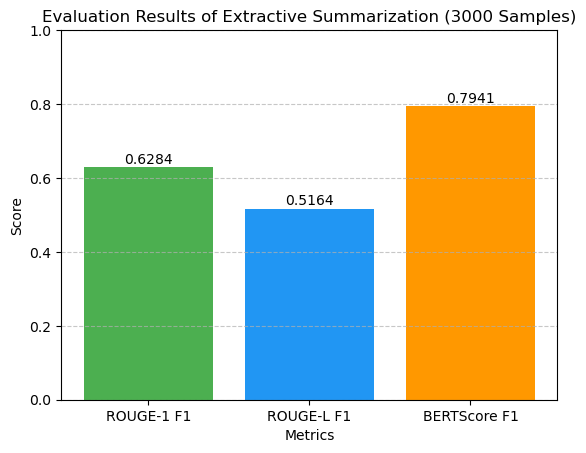

In [1]:
import matplotlib.pyplot as plt

# Dữ liệu
metrics = ['ROUGE-1 F1', 'ROUGE-L F1', 'BERTScore F1']
scores = [0.6284, 0.5164, 0.7941]

# Màu sắc (tùy chỉnh)
colors = ['#4CAF50', '#2196F3', '#FF9800']  # xanh lá, xanh dương, cam

# Tạo biểu đồ
plt.figure()
plt.bar(metrics, scores, color=colors)

# Tiêu đề và nhãn
plt.title('Evaluation Results of Extractive Summarization (3000 Samples)')
plt.xlabel('Metrics')
plt.ylabel('Score')

# Hiển thị giá trị trên đầu cột
for i, v in enumerate(scores):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center', fontsize=10)

# Giới hạn trục Y
plt.ylim(0, 1)

# Grid nhẹ cho đẹp
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Hiển thị
plt.show()

In [ ]:
import pandas as pd

df1 = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset extractive\Data_TX_train.xlsx")


In [3]:
df2 = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset extractive\Data_TX_train_.xlsx")
df3 = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset extractive\Data_TX_train_11.xlsx")

In [ ]:
df3

In [1]:


# ============================================================
# 3. PIPELINE TÓM TẮT
# ============================================================

import pandas as pd
from vncorenlp import VnCoreNLP
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("VoVanPhuc/sup-SimCSE-VietNamese-phobert-base")

vncorenlp = VnCoreNLP(
    "../../VnCoreNLP-master/VnCoreNLP-1.2.jar",
    annotators="wseg"
)

# ============================================================
# 1. CHUẨN HÓA VĂN BẢN
# ============================================================
import re

def normalize_text(text: str) -> str:
    """
    Bỏ dấu gạch dưới do VnCoreNLP ghép token (con_nước → con nước),
    chuẩn hóa khoảng trắng trước dấu câu, và dọn khoảng trắng thừa.
    """
    # Bỏ dấu _ giữa các token VnCoreNLP
    text = text.replace("_", " ")

    # Xóa khoảng trắng TRƯỚC dấu câu , . ! ? ; : ) ]
    text = re.sub(r'\s+([,\.!?;:\)\]])', r'\1', text)

    # Thêm khoảng trắng SAU dấu câu nếu chưa có (trừ số thập phân)
    text = re.sub(r'([,\.!?;:])(?!\s)(?!\d)', r'\1 ', text)

    # Xóa khoảng trắng SAU dấu mở ngoặc ( [
    text = re.sub(r'([\(\[])\s+', r'\1', text)

    # Xóa khoảng trắng thừa
    text = re.sub(r' +', ' ', text).strip()

    return text


def sentence_split(text: str) -> list[str]:
    sentences = []
    for sent in vncorenlp.annotate(text)["sentences"]:
        raw = " ".join([w["form"] for w in sent])
        sentences.append(normalize_text(raw))      # chuẩn hóa ngay khi tách
    return sentences


def textrank(sentences):
    tfidf = TfidfVectorizer().fit_transform(sentences)
    sim   = cosine_similarity(tfidf)
    graph = nx.from_numpy_array(sim)
    scores = nx.pagerank(graph)
    return scores

def lexrank(sentences):
    tfidf  = TfidfVectorizer().fit_transform(sentences)
    sim    = cosine_similarity(tfidf)
    scores = sim.sum(axis=1)
    return dict(enumerate(scores))

def filter_by_ratio(sentences, ratio=0.7):
    tr = textrank(sentences)
    lr = lexrank(sentences)
    combined = {i: 0.5 * tr[i] + 0.5 * lr[i] for i in range(len(sentences))}
    k       = max(1, int(len(sentences) * ratio))
    top_ids = sorted(combined, key=combined.get, reverse=True)[:k]
    return [sentences[i] for i in sorted(top_ids)]

def phobert_scoring(sentences, full_text):
    sent_emb = model.encode(sentences, normalize_embeddings=True)
    doc_emb  = model.encode([full_text], normalize_embeddings=True)[0]
    return sent_emb @ doc_emb

def mmr(sentences, scores, lambda_=0.8, top_k=5):
    sent_emb   = model.encode(sentences, normalize_embeddings=True)
    selected   = []
    candidates = list(range(len(sentences)))

    for _ in range(top_k):
        mmr_scores = []
        for i in candidates:
            redundancy = max(
                [sent_emb[i] @ sent_emb[j] for j in selected],
                default=0
            )
            mmr_score = lambda_ * scores[i] - (1 - lambda_) * redundancy
            mmr_scores.append((i, mmr_score))

        best = max(mmr_scores, key=lambda x: x[1])[0]
        selected.append(best)
        candidates.remove(best)

    return [sentences[i] for i in sorted(selected)]


def extractive_summary(
    text: str,
    filter_ratio: float = 0.7,
    mmr_ratio: float = 0.5,
    lambda_: float = 0.8
) -> str:

    # 1. Tách câu
    sentences = sentence_split(text)

    if len(sentences) == 0:
        return ""

    if len(sentences) == 1:
        return sentences[0]

    # 2. Filter bằng TextRank + LexRank
    filtered_sentences = filter_by_ratio(sentences, ratio=filter_ratio)

    # 3. Scoring bằng PhoBERT
    scores = phobert_scoring(filtered_sentences, text)

    # 4. MMR để chọn câu đa dạng
    top_k = max(1, int(len(filtered_sentences) * mmr_ratio))
    selected_sentences = mmr(
        filtered_sentences,
        scores,
        lambda_=lambda_,
        top_k=top_k
    )

    # 5. Ghép lại summary
    summary = " ".join(selected_sentences)

    return summary


# ============================================================
# 4. ÁP DỤNG CHO DATAFRAME
# ============================================================

def summarize_dataframe(
    df: pd.DataFrame,
    content_col: str = "content",
    summary_col: str = "summary",
    filter_ratio: float = 0.7,
    mmr_ratio: float = 0.5,
    lambda_: float = 0.8
):

    summaries = []

    for idx, text in enumerate(df[content_col]):
        try:
            summary = extractive_summary(
                text,
                filter_ratio=filter_ratio,
                mmr_ratio=mmr_ratio,
                lambda_=lambda_
            )
        except Exception as e:
            print(f"Lỗi tại dòng {idx}: {e}")
            summary = ""

        summaries.append(summary)

        if idx % 10 == 0:
            print(f"Đã xử lý {idx} dòng...")

    df[summary_col] = summaries
    return df


# ============================================================
# 5. CHẠY THỰC TẾ
# ============================================================

if __name__ == "__main__":

    # Load dữ liệu
    df = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset extractive\DATA_TX_work.xlsx")  # hoặc .xlsx

    # Tóm tắt
    df = summarize_dataframe(
        df,
        content_col="content",
        summary_col="summary",
        filter_ratio=0.7,
        mmr_ratio=0.5,
        lambda_=0.8
    )

    # Lưu kết quả
    df.to_excel("E:\Project_NguyenMinhVu_2211110063\Source\datasets\dataset extractive\DATA_TX_work_sumnew.xlsx", index=False)

    print("✅ Hoàn thành tóm tắt!")

c:\Users\minhv\anaconda3\envs\pytorch-env\lib\site-packages\networkx\utils\backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))
No sentence-transformers model found with name VoVanPhuc/sup-SimCSE-VietNamese-phobert-base. Creating a new one with mean pooling.


Đã xử lý 0 dòng...
Đã xử lý 10 dòng...
Đã xử lý 20 dòng...
Đã xử lý 30 dòng...
Đã xử lý 40 dòng...
Đã xử lý 50 dòng...
Đã xử lý 60 dòng...
Đã xử lý 70 dòng...
Đã xử lý 80 dòng...
Đã xử lý 90 dòng...
Đã xử lý 100 dòng...
Đã xử lý 110 dòng...
Đã xử lý 120 dòng...
Đã xử lý 130 dòng...
Đã xử lý 140 dòng...
Đã xử lý 150 dòng...
Đã xử lý 160 dòng...
Đã xử lý 170 dòng...
Đã xử lý 180 dòng...
Đã xử lý 190 dòng...
Đã xử lý 200 dòng...
Đã xử lý 210 dòng...
Đã xử lý 220 dòng...
Đã xử lý 230 dòng...
Đã xử lý 240 dòng...
Đã xử lý 250 dòng...
Đã xử lý 260 dòng...
Đã xử lý 270 dòng...
Đã xử lý 280 dòng...
Đã xử lý 290 dòng...
Đã xử lý 300 dòng...
Đã xử lý 310 dòng...
Đã xử lý 320 dòng...
Đã xử lý 330 dòng...
Đã xử lý 340 dòng...
Đã xử lý 350 dòng...
Đã xử lý 360 dòng...
Đã xử lý 370 dòng...
Đã xử lý 380 dòng...
Đã xử lý 390 dòng...
Đã xử lý 400 dòng...
Đã xử lý 410 dòng...
Đã xử lý 420 dòng...
Đã xử lý 430 dòng...
Đã xử lý 440 dòng...
Đã xử lý 450 dòng...
Đã xử lý 460 dòng...
Đã xử lý 470 dòng...
Đã 

In [4]:
import json
import re
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI

load_dotenv()

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.3,
    top_p=0.9,
    max_tokens=512,
)

PROJECT_ROOT = Path(r"E:\Project_NguyenMinhVu_2211110063")
INPUT_XLSX = PROJECT_ROOT / "Source" / "datasets" / "datatest" / "datatest_filtered_list_sentences.xlsx"
OUTPUT_XLSX = PROJECT_ROOT / "Source" / "datasets" / "datatest" / "datatest_sum__model_gpt_ex.xlsx"
SAVE_EVERY = 50


def parse_numbered_sentences(raw: str) -> list[str]:
    sents: list[str] = []
    for ln in raw.replace("\r\n", "\n").split("\n"):
        ln = ln.strip()
        if not ln:
            continue
        m = re.match(r"^\d+[.)]\s*(.*)$", ln)
        if m:
            sents.append(m.group(1).strip())
    if not sents and raw.strip():
        return [raw.strip()]
    return [s for s in sents if s]


MAX_RETRIES_PARSE = 3


def _strip_json_fence(raw: str) -> str:
    raw = raw.strip()
    if raw.startswith("```"):
        raw = re.sub(r"^```(?:json)?\s*", "", raw, flags=re.IGNORECASE)
        raw = re.sub(r"\s*```$", "", raw)
    return raw.strip()


def gpt_select_sentence_indices(sentences: list[str], k: int, grade: int) -> list[int]:
    """Bước 1 — chỉ trả về list chỉ số 1-based, ví dụ [1, 3, 5, 7]."""
    n = len(sentences)
    kk = min(n, max(1, k))
    lines = "\n".join(f"{i + 1}. {s}" for i, s in enumerate(sentences))
    messages = [
        SystemMessage(
            content=f"Bạn chỉ trả về JSON hợp lệ, không có văn bản khác; giáo viên tiếng Việt lớp {grade}."
        ),
        HumanMessage(
            content=f"""Đánh số câu 1..{n} (đúng như sau):
{lines}

Chọn đúng {kk} chỉ số câu quan trọng nhất (khoảng 40%; bắt buộc đúng {kk} phần tử).
Thứ tự trong JSON: theo thứ tự số của câu trong văn bản (tăng dần), ví dụ [1, 3, 5, 7].

Chỉ trả về một mảng JSON duy nhất, không markdown, không giải thích. Ví dụ hợp lệ:
[1, 3, 5]
"""
        ),
    ]
    small_llm = llm.bind(max_tokens=128, temperature=0.1)
    raw = small_llm.invoke(messages).content.strip()
    parsed = json.loads(_strip_json_fence(raw))
    if not isinstance(parsed, list):
        raise ValueError("Model không trả về list")
    out: list[int] = []
    seen: set[int] = set()
    for x in parsed:
        try:
            i = int(x)
        except (TypeError, ValueError):
            continue
        if 1 <= i <= n and i not in seen:
            seen.add(i)
            out.append(i)
    out.sort()
    if len(out) < kk:
        for j in range(1, n + 1):
            if j not in seen:
                seen.add(j)
                out.append(j)
            if len(out) == kk:
                break
        out.sort()
    elif len(out) > kk:
        out = sorted(out)[:kk]
    return sorted(out[:kk])


def map_indices_to_sentences(sentences: list[str], indices_1based: list[int]) -> list[str]:
    """Đối chiếu chỉ số với danh sách câu đã parse (thứ tự index tăng dần)."""
    n = len(sentences)
    selected: list[str] = []
    for i in sorted(set(indices_1based)):
        if 1 <= i <= n:
            selected.append(sentences[i - 1])
    return selected


def join_selected_sentences_manual(selected: list[str]) -> str:
    """Ghép các câu đã chọn thành một đoạn (nối bằng khoảng trắng, không gọi GPT)."""
    parts = [s.strip() for s in selected if isinstance(s, str) and s.strip()]
    return " ".join(parts)


def extractive_via_indices_then_join(
    sentences: list[str], k: int, grade: int
) -> str:
    for attempt in range(MAX_RETRIES_PARSE):
        try:
            idx_list = gpt_select_sentence_indices(sentences, k, grade)
        except Exception:
            continue
        picked = map_indices_to_sentences(sentences, idx_list)
        if picked:
            return join_selected_sentences_manual(picked)
    kk_fallback = min(len(sentences), max(1, k))
    picked = map_indices_to_sentences(
        sentences, list(range(1, kk_fallback + 1))
    )
    if not picked:
        return ""
    return join_selected_sentences_manual(picked)


df = pd.read_excel(INPUT_XLSX)
if "summary" not in df.columns:
    df["summary"] = ""
if "sentences_text" not in df.columns:
    raise ValueError("Thiếu cột sentences_text")

processed = 0
for idx, row in df.iterrows():
    existing = row.get("summary", "")
    if pd.notna(existing) and str(existing).strip():
        continue

    raw = row.get("sentences_text", "")
    if pd.isna(raw) or not str(raw).strip():
        df.loc[idx, "summary"] = ""
        continue

    # B1: GPT chỉ trả list chỉ số → B2: đối chiếu sentences_tmp → B3: ghép thủ công (không GPT)
    sentences_tmp = parse_numbered_sentences(str(raw))
    if not sentences_tmp:
        df.loc[idx, "summary"] = ""
        continue

    n = len(sentences_tmp)
    k = min(n, max(1, round(n * 0.4)))
    try:
        grade = int(row["grade"])
    except (TypeError, ValueError):
        grade = 5

    try:
        text = extractive_via_indices_then_join(sentences_tmp, k, grade)
    except Exception as e:
        print(f"Lỗi dòng {idx}: {e}")
        text = ""

    df.loc[idx, "summary"] = text
    processed += 1

    if processed > 0 and processed % SAVE_EVERY == 0:
        df.to_excel(OUTPUT_XLSX, index=False, engine="openpyxl")
        print(f"Đã lưu checkpoint sau {processed} dòng xử lý")

df.to_excel(OUTPUT_XLSX, index=False, engine="openpyxl")
print(f"Hoàn tất. Đã lưu: {OUTPUT_XLSX} | Dòng vừa chạy mới trong lần này: {processed}")


C:\Users\minhv\AppData\Local\Temp\ipykernel_21448\3198245568.py:172: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Em rất kính trọng thầy Hoàng. Giọng nói của thầy rất ấm áp, truyền cảm. Em mong thầy luôn khoẻ mạnh để tiếp tục dạy dỗ nhiều thế hệ học sinh nên người.' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[idx, "summary"] = text


Đã lưu checkpoint sau 50 dòng xử lý
Đã lưu checkpoint sau 100 dòng xử lý
Đã lưu checkpoint sau 150 dòng xử lý
Đã lưu checkpoint sau 200 dòng xử lý
Đã lưu checkpoint sau 250 dòng xử lý
Đã lưu checkpoint sau 300 dòng xử lý
Đã lưu checkpoint sau 350 dòng xử lý
Đã lưu checkpoint sau 400 dòng xử lý
Đã lưu checkpoint sau 450 dòng xử lý
Đã lưu checkpoint sau 500 dòng xử lý
Đã lưu checkpoint sau 550 dòng xử lý
Đã lưu checkpoint sau 600 dòng xử lý
Đã lưu checkpoint sau 650 dòng xử lý
Đã lưu checkpoint sau 700 dòng xử lý
Đã lưu checkpoint sau 750 dòng xử lý
Đã lưu checkpoint sau 800 dòng xử lý
Đã lưu checkpoint sau 850 dòng xử lý
Đã lưu checkpoint sau 900 dòng xử lý
Đã lưu checkpoint sau 950 dòng xử lý
Đã lưu checkpoint sau 1000 dòng xử lý
Đã lưu checkpoint sau 1050 dòng xử lý
Đã lưu checkpoint sau 1100 dòng xử lý
Đã lưu checkpoint sau 1150 dòng xử lý
Đã lưu checkpoint sau 1200 dòng xử lý
Đã lưu checkpoint sau 1250 dòng xử lý
Đã lưu checkpoint sau 1300 dòng xử lý
Đã lưu checkpoint sau 1350 dòng 

In [5]:
import pandas as pd 
import nltk
import numpy as np
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from vncorenlp import VnCoreNLP
import torch
from transformers import BertTokenizer, BertModel

SAVE_EVERY = 50

rdrsegmenter = VnCoreNLP(
    "../../VnCoreNLP-master/VnCoreNLP-1.2.jar", 
    annotators="wseg"
)

class BertSumExtractor:
    def __init__(self, model_name='bert-base-uncased'):
        self.tokenizer = BertTokenizer.from_pretrained(model_name)
        self.model = BertModel.from_pretrained(model_name)
        self.model.eval()

    def encode_sentences(self, sentences):
        inputs = self.tokenizer(
            sentences,
            padding=True,
            truncation=True,
            return_tensors="pt",
            max_length=128
        )

        with torch.no_grad():
            outputs = self.model(**inputs)

        # Lấy embedding [CLS]
        cls_embeddings = outputs.last_hidden_state[:, 0, :]
        return cls_embeddings

    def summarize(self, text, top_k=3):
        sentences = nltk.sent_tokenize(text)

        if len(sentences) <= top_k:
            return " ".join(sentences)

        embeddings = self.encode_sentences(sentences)

        # Tính importance score (norm vector)
        scores = torch.norm(embeddings, dim=1)

        ranked = sorted(
            [(scores[i].item(), sentences[i], i) for i in range(len(sentences))],
            reverse=True
        )

        selected = sorted(ranked[:top_k], key=lambda x: x[2])

        summary = " ".join([s for (_, s, _) in selected])
        return summary

def count_sentences_vncorenlp(text, rdrsegmenter):
    annotated = rdrsegmenter.annotate(text)
    
    return len(annotated['sentences'])

nltk.download('punkt')

def textrank_summarize(text, top_k=3):
    # 1. Tách câu
    sentences = nltk.sent_tokenize(text)
    
    if len(sentences) <= top_k:
        return " ".join(sentences)

    # 2. TF-IDF vector
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(sentences)

    # 3. Similarity matrix
    sim_matrix = cosine_similarity(tfidf_matrix)

    # 4. Build graph
    graph = nx.from_numpy_array(sim_matrix)

    # 5. PageRank
    scores = nx.pagerank(graph)

    # 6. Rank câu
    ranked_sentences = sorted(
        ((scores[i], s, i) for i, s in enumerate(sentences)),
        reverse=True
    )

    # 7. Chọn top_k câu
    selected = sorted(ranked_sentences[:top_k], key=lambda x: x[2])

    # 8. Ghép lại theo thứ tự gốc
    summary = " ".join([s for (_, s, _) in selected])

    return summary

def lexrank_summarize(text, top_k=3, threshold=0.1):
    # 1. Tách câu
    sentences = nltk.sent_tokenize(text)

    if len(sentences) <= top_k:
        return " ".join(sentences)

    # 2. TF-IDF vector
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(sentences)

    # 3. Similarity matrix
    sim_matrix = cosine_similarity(tfidf_matrix)

    # 4. Apply threshold (quan trọng của LexRank)
    sim_matrix[sim_matrix < threshold] = 0

    # 5. Build graph
    graph = nx.from_numpy_array(sim_matrix)

    # 6. PageRank
    scores = nx.pagerank(graph)

    # 7. Rank câu
    ranked_sentences = sorted(
        ((scores[i], s, i) for i, s in enumerate(sentences)),
        reverse=True
    )

    # 8. Chọn top_k câu
    selected = sorted(ranked_sentences[:top_k], key=lambda x: x[2])

    # 9. Ghép lại đúng thứ tự
    summary = " ".join([s for (_, s, _) in selected])

    return summary

def lead_k(text, k=3):
    sentences = nltk.sent_tokenize(text)
    return " ".join(sentences[:k])

df = pd.read_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\datatest\datatest_filtered.xlsx")

if "summary_lead_5" not in df.columns:
    df["summary_lead_5"] = ""
    
model = BertSumExtractor()

processed = 0
for idx, row in df.iterrows():
    existing = row.get("summary_lead_5", "")
    if pd.notna(existing) and str(existing).strip():
        continue
    n = count_sentences_vncorenlp(df.loc[idx, "content"], rdrsegmenter)
    k = min(n, max(1, round(n * 0.4)))
    # text = lead_k(df.loc[idx, "content"], k)
    # text = textrank_summarize(df.loc[idx, "content"], k)
    # text = lexrank_summarize(df.loc[idx, "content"], k)
    text = model.summarize(df.loc[idx, "content"], top_k=k)
    
    df.loc[idx, "summary_lead_5"] = text
    processed += 1

df.to_excel(r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\datatest\datatest_sum_BERTSUM.xlsx", index=False, engine="openpyxl")


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\minhv\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [6]:
"""
Batch Extractive Summarization — All-in-one Script
===================================================
Model  : PhoBERTSUM (fine-tuned)
Input  : E:\\Project_NguyenMinhVu_2211110063\\Source\\datasets\\dataset abstractive\\Data_test_1000.xlsx
Output : E:\\Project_NguyenMinhVu_2211110063\\Source\\datasets\\dataset abstractive\\Data_test_1000_extract.xlsx

Chạy nhanh:
    python batch_extract.py
    python batch_extract.py --ratio 0.4
    python batch_extract.py --resume
    python batch_extract.py --content-col "noi_dung" --out-col "tom_tat"
"""

# ===========================================================
# IMPORTS
# ===========================================================
import argparse
import sys
import time
from pathlib import Path
from typing import Optional

import torch
import torch.nn as nn
import pandas as pd
from transformers import AutoTokenizer, AutoModel
from nltk.tokenize import sent_tokenize

# ===========================================================
# ▶▶ CẤU HÌNH — chỉnh tại đây nếu không dùng CLI ◀◀
# ===========================================================
INPUT_PATH   = r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\datatest\datatest_filtered.xlsx"
OUTPUT_PATH  = r"E:\Project_NguyenMinhVu_2211110063\Source\datasets\datatest\datatest_sum_mymodel.xlsx"
MODEL_PATH   = r"E:\Project_NguyenMinhVu_2211110063\Source\ai\Model Train\Model_TX_ver3\final_best_model.pt"
ENCODER_NAME = "vinai/phobert-large"

COL_CONTENT  = "content"      # cột văn bản gốc
COL_OUT      = "summary_model"  # cột kết quả — ghi vào cột có sẵn trong file

DEFAULT_RATIO    = 0.4   # tỉ lệ câu giữ lại (0.0 – 1.0)
MAX_LEN          = 128   # max token mỗi câu khi encode
CHECKPOINT_EVERY = 50    # lưu checkpoint sau mỗi N dòng

# ===========================================================
# MODEL DEFINITION
# ===========================================================

class PhoBERTSUM(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder    = encoder
        hidden = encoder.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Linear(hidden, 256),   # layer 0
            nn.ReLU(),                # layer 1
            nn.Dropout(0.3),          # layer 2
            nn.Linear(256, 1)         # layer 3
        )

    def forward(self, input_ids, attention_mask):
        outputs  = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls_emb  = outputs.last_hidden_state[:, 0, :]  # ✅ CLS pooling
        return self.classifier(cls_emb)


# ===========================================================
# EXTRACTOR AGENT
# ===========================================================

class ExtractorAgent:
    """PhoBERTSUM extractive summarizer."""

    def __init__(
        self,
        model_path:   str = MODEL_PATH,
        encoder_name: str = ENCODER_NAME,
        max_len:      int = MAX_LEN,
    ):
        self.model_path   = model_path
        self.encoder_name = encoder_name
        self.max_len      = max_len
        self.device       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self._load_model()

    # ── model loading ────────────────────────────────────────

    def _load_model(self):
        self.tokenizer = AutoTokenizer.from_pretrained(self.encoder_name, use_fast=False)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token

        encoder    = AutoModel.from_pretrained(self.encoder_name).to(self.device)
        self.model = PhoBERTSUM(encoder).to(self.device)

        checkpoint = torch.load(self.model_path, map_location=self.device)
        self.model.load_state_dict(checkpoint["model_state"])
        self.model.eval()

    # ── utilities ────────────────────────────────────────────

    def _split_sentences(self, text: str) -> list:
        if not isinstance(text, str):
            return []
        return [s.strip() for s in sent_tokenize(text) if len(s.strip()) > 10]

    # ── core extractive logic ─────────────────────────────────

    @torch.no_grad()
    def extract(self, text: str, ratio: float = 0.5) -> str:
        sentences = self._split_sentences(text)
        n         = len(sentences)

        if n == 0:
            return ""
        if n == 1:
            return sentences[0]

        top_k   = max(1, int(n * ratio))
        encoded = self.tokenizer(
            sentences,
            padding=True,
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt",
        )

        input_ids      = encoded["input_ids"].to(self.device)
        attention_mask = encoded["attention_mask"].to(self.device)

        scores  = self.model(input_ids=input_ids, attention_mask=attention_mask)
        scores  = scores.squeeze().cpu()

        top_idx = torch.topk(scores, min(top_k, n)).indices.tolist()
        if not isinstance(top_idx, list):
            top_idx = [top_idx]
        top_idx.sort()

        return " ".join(sentences[i] for i in top_idx).strip()

    # ── public API ───────────────────────────────────────────

    def run(self, text: str, ratio: float = 0.5) -> str:
        try:
            return self.extract(text, ratio=ratio)
        except Exception as e:
            return f"[Error] {e}"


# ===========================================================
# BATCH RUNNER
# ===========================================================

def parse_args():
    p = argparse.ArgumentParser(description="Batch extractive summarization từ Excel")
    p.add_argument("--input",        default=INPUT_PATH)
    p.add_argument("--output",       default=OUTPUT_PATH)
    p.add_argument("--model",        default=MODEL_PATH)
    p.add_argument("--encoder",      default=ENCODER_NAME)
    p.add_argument("--content-col",  default=COL_CONTENT)
    p.add_argument("--out-col",      default=COL_OUT)
    p.add_argument("--ratio",        type=float, default=DEFAULT_RATIO,
                   help="Tỉ lệ câu giữ lại, ví dụ 0.5 = 50%% số câu")
    p.add_argument("--max-len",      type=int, default=MAX_LEN)
    p.add_argument("--checkpoint",   type=int, default=CHECKPOINT_EVERY)
    p.add_argument("--resume",       action="store_true",
                   help="Tiếp tục: bỏ qua dòng đã có kết quả trong file output")
    # Bỏ qua tham số lạ do Jupyter tự thêm (--f=kernel-xxx.json)
    args, _ = p.parse_known_args()
    return args


def load_dataframe(args) -> pd.DataFrame:
    out_path = Path(args.output)
    if args.resume and out_path.exists():
        df = pd.read_excel(args.output, dtype=str)
        print(f"[INFO] Resume từ output: {args.output} ({len(df)} dòng)")
    else:
        df = pd.read_excel(args.input, dtype=str)
        print(f"[INFO] Đọc input: {args.input} ({len(df)} dòng)")
    if args.out_col not in df.columns:
        df[args.out_col] = ""
    return df


def run_batch(args):
    bar = "=" * 62
    print(bar)
    print("  BATCH EXTRACTIVE SUMMARIZATION")
    print(bar)
    print(f"  Input       : {args.input}")
    print(f"  Output      : {args.output}")
    print(f"  Model       : {args.model}")
    print(f"  Encoder     : {args.encoder}")
    print(f"  Content col : {args.content_col}")
    print(f"  Output col  : {args.out_col}")
    print(f"  Ratio       : {args.ratio}  (giữ {int(args.ratio*100)}% số câu)")
    print(f"  Resume      : {args.resume}")
    print(bar)

    print("[INFO] Đang tải model PhoBERTSUM...")
    agent = ExtractorAgent(
        model_path   = args.model,
        encoder_name = args.encoder,
        max_len      = args.max_len,
    )
    print(f"[INFO] Thiết bị: {agent.device}\n")

    df = load_dataframe(args)

    if args.content_col not in df.columns:
        sys.exit(
            f"[ERROR] Cột '{args.content_col}' không tồn tại.\n"
            f"  Các cột hiện có: {list(df.columns)}"
        )

    total     = len(df)
    processed = skipped = errors = 0
    t0        = time.time()

    for idx in range(total):
        row = df.iloc[idx]

        # Resume: bỏ qua dòng đã có kết quả
        if args.resume:
            val = str(row.get(args.out_col, "")).strip()
            if val and val.lower() not in ("", "nan"):
                skipped += 1
                continue

        content = str(row.get(args.content_col, "")).strip()
        if not content or content.lower() == "nan":
            df.at[idx, args.out_col] = ""
            continue

        # Tóm tắt trích xuất
        try:
            result = agent.run(content, ratio=args.ratio)
        except Exception as e:
            result = f"[ERROR] {e}"
            errors += 1

        df.at[idx, args.out_col] = result
        processed += 1

        # Progress log
        elapsed = time.time() - t0
        avg_sec = elapsed / processed
        eta_min = avg_sec * (total - skipped - processed) / 60
        print(
            f"  [{skipped + processed:>5}/{total}] row={idx} | "
            f"{len(content)}→{len(result)} ký tự | ETA {eta_min:.1f} phút",
            flush=True,
        )

        # Checkpoint
        if processed % args.checkpoint == 0:
            df.to_excel(args.output, index=False)
            print(f"  ✔ Checkpoint → {args.output}")

    # Lưu cuối
    df.to_excel(args.output, index=False)

    total_min = (time.time() - t0) / 60
    print(f"\n{bar}")
    print("  HOÀN TẤT")
    print(f"  Đã xử lý  : {processed} dòng")
    print(f"  Bỏ qua    : {skipped} dòng")
    print(f"  Lỗi       : {errors} dòng")
    print(f"  Thời gian : {total_min:.1f} phút")
    print(f"  Lưu tại   : {args.output}")
    print(bar)


# ===========================================================
# ENTRY POINT
# ===========================================================
if __name__ == "__main__":
    run_batch(parse_args())

  BATCH EXTRACTIVE SUMMARIZATION
  Input       : E:\Project_NguyenMinhVu_2211110063\Source\datasets\datatest\datatest_filtered.xlsx
  Output      : E:\Project_NguyenMinhVu_2211110063\Source\datasets\datatest\datatest_sum_mymodel.xlsx
  Model       : E:\Project_NguyenMinhVu_2211110063\Source\ai\Model Train\Model_TX_ver3\final_best_model.pt
  Encoder     : vinai/phobert-large
  Content col : content
  Output col  : summary_model
  Ratio       : 0.4  (giữ 40% số câu)
  Resume      : False
[INFO] Đang tải model PhoBERTSUM...
[INFO] Thiết bị: cuda

[INFO] Đọc input: E:\Project_NguyenMinhVu_2211110063\Source\datasets\datatest\datatest_filtered.xlsx (4983 dòng)
  [    1/4983] row=0 | 398→130 ký tự | ETA 46.8 phút
  [    2/4983] row=1 | 479→155 ký tự | ETA 31.4 phút
  [    3/4983] row=2 | 300→88 ký tự | ETA 23.2 phút
  [    4/4983] row=3 | 438→130 ký tự | ETA 20.4 phút
  [    5/4983] row=4 | 285→109 ký tự | ETA 17.5 phút
  [    6/4983] row=5 | 283→86 ký tự | ETA 15.7 phút
  [    7/4983] row=6 